In [1]:
import os

os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np

np.set_printoptions(suppress=True)
np.random.seed(1)
import random

random.seed(1)
import pandas as pd

pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series
import seaborn as sns

sns.set_style("whitegrid")
import matplotlib.pyplot as plt
%matplotlib inline

plt.style.use("ggplot")
plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "figure.dpi": 100,
        "savefig.dpi": 300,
        "figure.constrained_layout.use": True,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "grid.alpha": 1.0,
    }
)
import matplotlib as mpl
from cycler import cycler

mpl.rcParams["axes.prop_cycle"] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series as plot_series_fpppy

mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#0072B2", "#D55E00"],
        name="black_and_2color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73"],
        name="black_and_3color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="black_and_4color",
    ),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55E00", "#0072B2", "#009E73", "#CC79A7"],
        name="r_colors",
    ),
    force=True,
)

In [2]:
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
import statsmodels.api as sm
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf

mpl.rcParams["axes.prop_cycle"] = cycler(color=["#000000", "#2f2fff"])

# Basic functions


In [3]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range("2020-01-01", "2020-01-02", freq="8h")
print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


In [4]:
print(ts_range.to_period())
print(ts_range.to_period(freq="D"))
print(ts_range.to_period(freq="W"))
print(
    ts_range.to_period(freq="W-mon")
)  # W-mon indicates weeks starting on Monday and ending on Sunday.
print(ts_range.to_period().to_timestamp())

PeriodIndex(['2020-01-01 00:00', '2020-01-01 08:00', '2020-01-01 16:00',
             '2020-01-02 00:00'],
            dtype='period[8h]')
PeriodIndex(['2020-01-01', '2020-01-01', '2020-01-01', '2020-01-02'], dtype='period[D]')
PeriodIndex(['2019-12-30/2020-01-05', '2019-12-30/2020-01-05',
             '2019-12-30/2020-01-05', '2019-12-30/2020-01-05'],
            dtype='period[W-SUN]')
PeriodIndex(['2019-12-31/2020-01-06', '2019-12-31/2020-01-06',
             '2019-12-31/2020-01-06', '2019-12-31/2020-01-06'],
            dtype='period[W-MON]')
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


In [5]:
ts_few = pd.to_datetime(["2020-01-01", "2020-01-02", "2020-01-03"])
ts_range = pd.date_range("2020-01-01", "2020-01-02", freq="8h")
print(ts_few)
print(ts_range)

DatetimeIndex(['2020-01-01', '2020-01-02', '2020-01-03'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2020-01-01 00:00:00', '2020-01-01 08:00:00',
               '2020-01-01 16:00:00', '2020-01-02 00:00:00'],
              dtype='datetime64[ns]', freq='8h')


In [6]:
df = pd.DataFrame({"ts": ts_few})
df

,ts
0,2020-01-01
1,2020-01-02
2,2020-01-03


In [7]:
df = df.assign(
    period=df["ts"].dt.to_period(),
    yr=df["ts"].dt.year,
    str=df["ts"].dt.strftime("%A, %B %-d"),
).set_index("ts")
df

,period,yr,str
ts,,,
2020-01-01,2020-01-01,2020,2020-01-01 00:00:00
2020-01-02,2020-01-02,2020,2020-01-02 00:00:00
2020-01-03,2020-01-03,2020,2020-01-03 00:00:00


A dataset containing the fastest running times for women’s and men’s track races at the Olympics, from 100m to 10000m:


In [8]:
olympic_running = pd.read_csv("data/olympic_running_unparsed.csv")
olympic_running

,Year,Length,Sex,Time
0,1896,100,men,12.00
1,1900,100,men,11.00
2,1904,100,men,11.00
3,1908,100,men,10.80
4,1912,100,men,10.80
...,...,...,...,...
307,2000,10000,women,1817.49
308,2004,10000,women,1824.36
309,2008,10000,women,1794.66
310,2012,10000,women,1820.75


In [9]:
print(olympic_running[["Sex", "Length"]].drop_duplicates())

       Sex  Length
0      men     100
31   women     100
54     men     200
84   women     200
102    men     400
133  women     400
147    men     800
178  women     800
201    men    1500
232  women    1500
244    men    5000
271  women    5000
277    men   10000
304  women   10000


# Plots


## Time Plot


In [10]:
melsyd_economy = (
    pd.read_csv("data/ansett.csv", parse_dates=["ds"])
    .loc[lambda x: (x["Airports"] == "MEL-SYD") & (x["Class"] == "Economy")]
    .rename(columns={"Airports": "unique_id"})
    .assign(y=lambda x: x["y"] / 1000)
)

melsyd_economy.head()

,ds,unique_id,Class,y
3881,1987-06-22,MEL-SYD,Economy,20.167
3882,1987-06-29,MEL-SYD,Economy,20.161
3883,1987-07-06,MEL-SYD,Economy,19.993
3884,1987-07-13,MEL-SYD,Economy,20.986
3885,1987-07-20,MEL-SYD,Economy,20.497


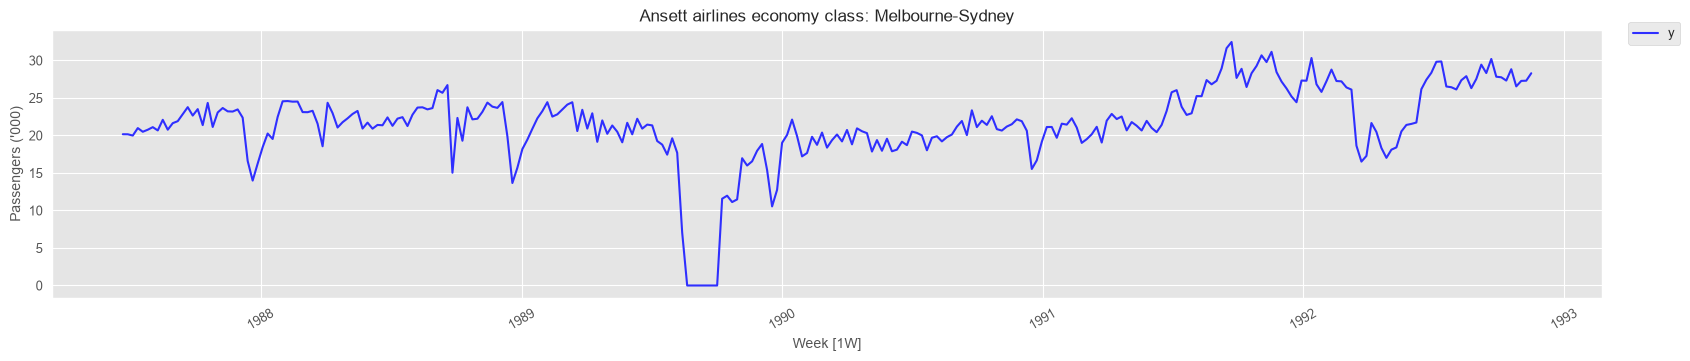

In [11]:
fig = plot_series(
    df=melsyd_economy,
    id_col="unique_id",
    time_col="ds",
    target_col="y",
)


ax = fig.axes[0]
ax.set_xlabel("Week [1W]")
ax.set_ylabel("Passengers ('000)")
ax.set_title("Ansett airlines economy class: Melbourne-Sydney")


fig

## Seasonal Plot


In [12]:
pbs = pd.read_csv("data/PBS_unparsed.csv", parse_dates=["Month"])
pbs = pbs[["Month", "Concession", "Type", "ATC1", "ATC2", "Scripts", "Cost"]]

In [13]:
total_cost_df = (
    pbs.loc[pbs["ATC2"] == "A10"]
    .drop(columns=["ATC1", "ATC2"])
    .groupby("Month", as_index=False)
    .agg({"Cost": "sum"})
    .assign(
        Cost=lambda x: (x["Cost"] / 1e6).round(2)
    )  # Cost from dollars to millions of dollars
)
total_cost_df

,Month,Cost
0,1991-07-01,3.53
1,1991-08-01,3.18
2,1991-09-01,3.25
3,1991-10-01,3.61
4,1991-11-01,3.57
...,...,...
199,2008-02-01,21.65
200,2008-03-01,18.26
201,2008-04-01,23.11
202,2008-05-01,22.91


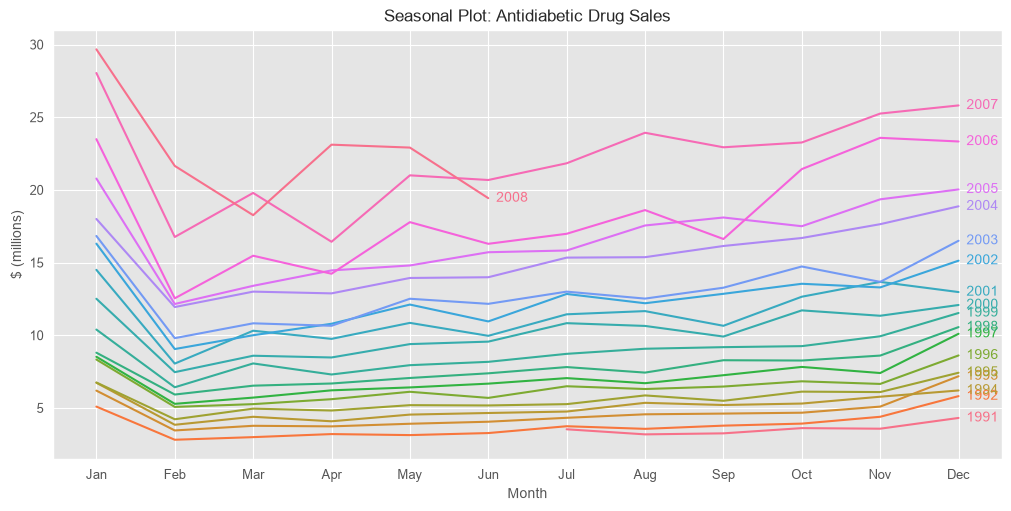

In [14]:
df = total_cost_df.assign(
    Year=total_cost_df["Month"].dt.year,
    Month_num=total_cost_df["Month"].dt.month,
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df,
    x="Month_num",
    y="Cost",
    hue="Year",
    palette="husl",
    legend=False,
    ax=ax,
)

ax.set(
    title="Seasonal Plot: Antidiabetic Drug Sales",
    xlabel="Month",
    ylabel="$ (millions)",
    xticks=range(1, 13),
    xticklabels=[
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
)

# Label each year's line
for year, data in df.groupby("Year"):
    last = data.iloc[-1]
    ax.text(
        last["Month_num"] + 0.1,
        last["Cost"],
        str(year),
        color=ax.lines[year - df["Year"].min()].get_color(),
        va="center",
    )

plt.show()

Manual Lag Example:
             price  price_lag_1
2023-01-01  10.993          NaN
2023-01-02  10.128       10.993
2023-01-03  12.103       10.128


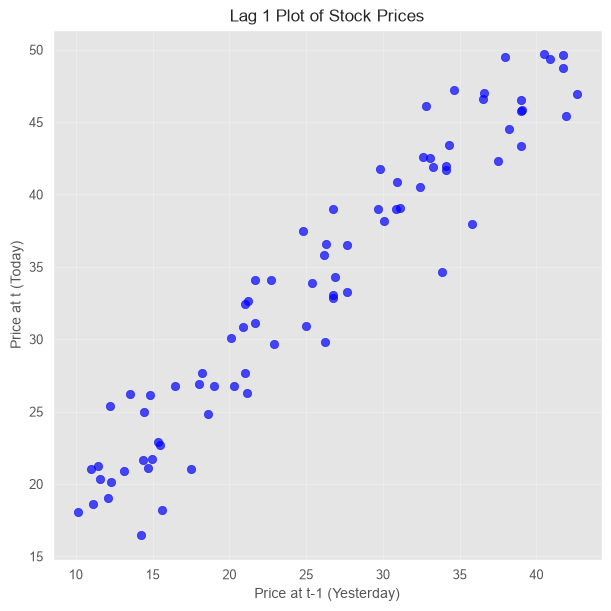

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot

# 1. Create synthetic data (A simple upward trend with some noise)
np.random.seed(42)
days = pd.date_range(start="2023-01-01", periods=100)
# A straight line going up + random noise
stock_prices = np.linspace(10, 50, 100) + np.random.normal(0, 2, 100)
df_stock = pd.DataFrame({"price": stock_prices}, index=days)

# 2. How lags work mechanically using .shift()
# .shift(1) pushes all data down by 1 row. The first row becomes NaN (Not a Number).
df_stock["price_lag_1"] = df_stock["price"].shift(1)
print("Manual Lag Example:")
print(df_stock.head(3))
# Output:
#             price  price_lag_1
# 2023-01-01  10.99          NaN
# 2023-01-02  10.12        10.99
# 2023-01-03  12.10        10.12

# 3. Build the Lag Plot (Pandas does the shifting automatically for the plot)
plt.figure(figsize=(6, 6))
# Plotting Lag 1 (Yesterday vs Today)
lag_plot(df_stock["price"], lag=20, c="blue", alpha=0.7)

plt.title("Lag 1 Plot of Stock Prices")
plt.xlabel("Price at t-1 (Yesterday)")
plt.ylabel("Price at t (Today)")
plt.grid(True, alpha=0.3)
plt.show()

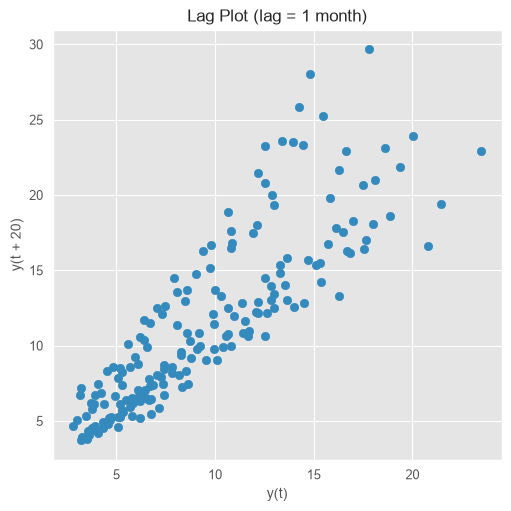

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

lag_plot(total_cost_df["Cost"], lag=20, ax=ax)

ax.set_title("Lag Plot (lag = 1 month)")
plt.show()

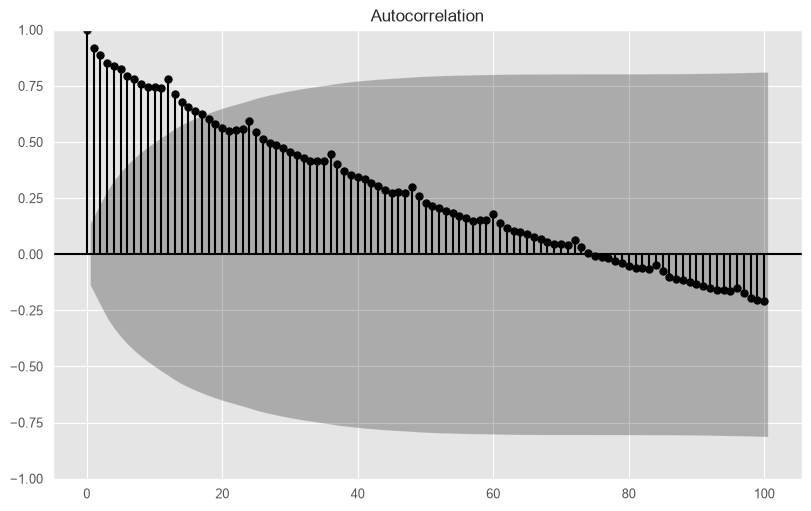

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(total_cost_df["Cost"], lags=100)
plt.show()

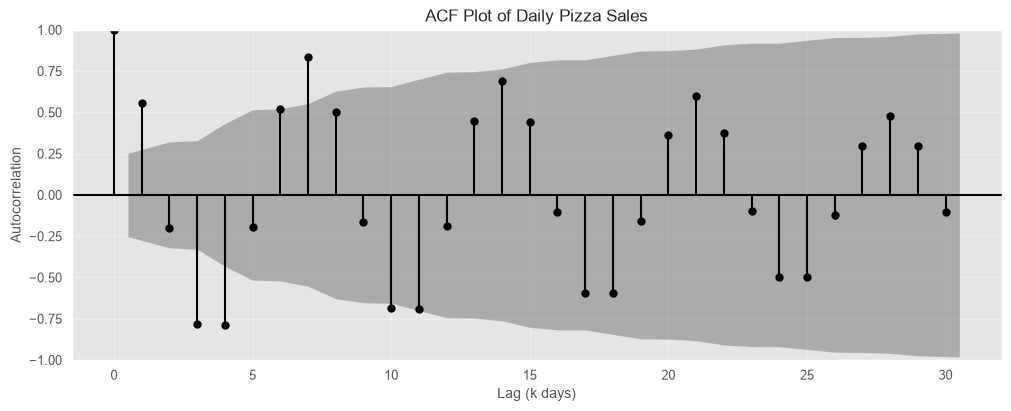

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

# 1. Create synthetic daily data with a weekly (7-day) seasonality
dates = pd.date_range(start="2023-01-01", periods=60, freq="D")
# Sine wave repeating every 7 days + random noise
pizza_sales = (
    np.sin(np.arange(60) * (2 * np.pi / 7)) * 50 + 100 + np.random.normal(0, 10, 60)
)
df_pizza = pd.DataFrame({"sales": pizza_sales}, index=dates)

# 2. Plot the ACF (Correlogram)
plt.figure(figsize=(10, 4))
# lags=30: Calculates correlation for t-1 all the way to t-30
# alpha=0.05: Draws the 95% confidence interval (blue band)
# ax=plt.gca(): Tells statsmodels to draw on our current matplotlib figure
plot_acf(df_pizza["sales"], lags=30, alpha=0.05, ax=plt.gca())

plt.title("ACF Plot of Daily Pizza Sales")
plt.xlabel("Lag (k days)")
plt.ylabel("Autocorrelation")
plt.grid(True, alpha=0.3)
plt.show()

# Decomposition


In [19]:
us_employment = pd.read_csv("data/us_employment.csv", parse_dates=["ds"])
us_retail_employment = us_employment.loc[
    lambda x: (x["unique_id"] == "Retail Trade") & (x["ds"] >= "1990")
]

us_retail_employment.head()

,ds,unique_id,y
50031,1990-01-01,Retail Trade,13255.8
50032,1990-02-01,Retail Trade,12966.3
50033,1990-03-01,Retail Trade,12938.2
50034,1990-04-01,Retail Trade,13012.3
50035,1990-05-01,Retail Trade,13108.3


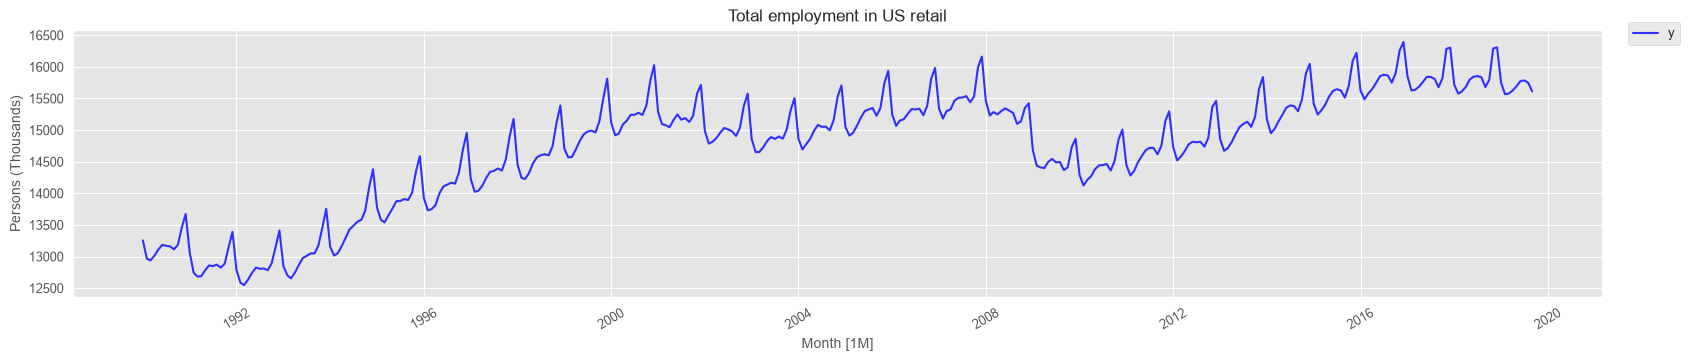

In [20]:
fig = plot_series(
    us_retail_employment, id_col="unique_id", time_col="ds", target_col="y"
)

ax = fig.axes[0]
ax.set_xlabel("Month [1M]")
ax.set_ylabel("Persons (Thousands)")
ax.set_title("Total employment in US retail")

fig

In [21]:
from statsmodels.tsa.seasonal import STL

stl = STL(us_retail_employment["y"], period=12)
res = stl.fit()

dcmp = pd.DataFrame(
    {
        "ds": us_retail_employment.ds,
        "data": us_retail_employment.y,
        "trend": res.trend,
        "seasonal": res.seasonal,
        "remainder": res.resid,
    }
).reset_index(drop=True)

dcmp.head(24)

,ds,data,trend,seasonal,remainder
0,1990-01-01,13255.8,13296.249,-3.700,-36.749
1,1990-02-01,12966.3,13276.085,-288.398,-21.387
2,1990-03-01,12938.2,13255.663,-306.658,-10.805
3,1990-04-01,13012.3,13234.986,-235.775,13.089
4,1990-05-01,13108.3,13214.071,-115.399,9.628
5,1990-06-01,13182.8,13192.930,-18.769,8.639
6,1990-07-01,13170.1,13171.575,-13.864,12.389
7,1990-08-01,13159.5,13150.019,5.902,3.579
8,1990-09-01,13113.4,13128.275,-24.533,9.658
9,1990-10-01,13185.2,13106.360,60.887,17.953


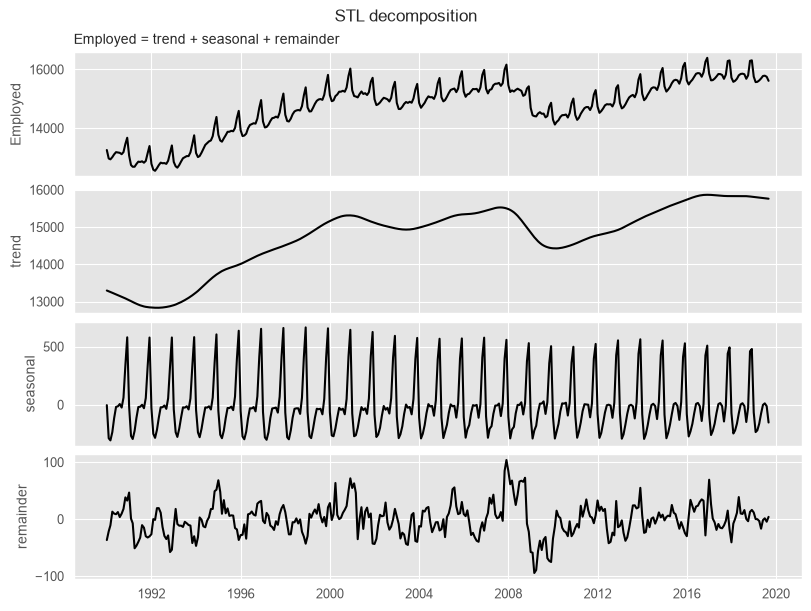

In [22]:
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(8, 6))
sns.lineplot(data=dcmp, x="ds", y="data", ax=axes[0])
sns.lineplot(data=dcmp, x="ds", y="trend", ax=axes[1])
sns.lineplot(data=dcmp, x="ds", y="seasonal", ax=axes[2])
sns.lineplot(data=dcmp, x="ds", y="remainder", ax=axes[3])
axes[0].set_title("Employed = trend + seasonal + remainder", size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

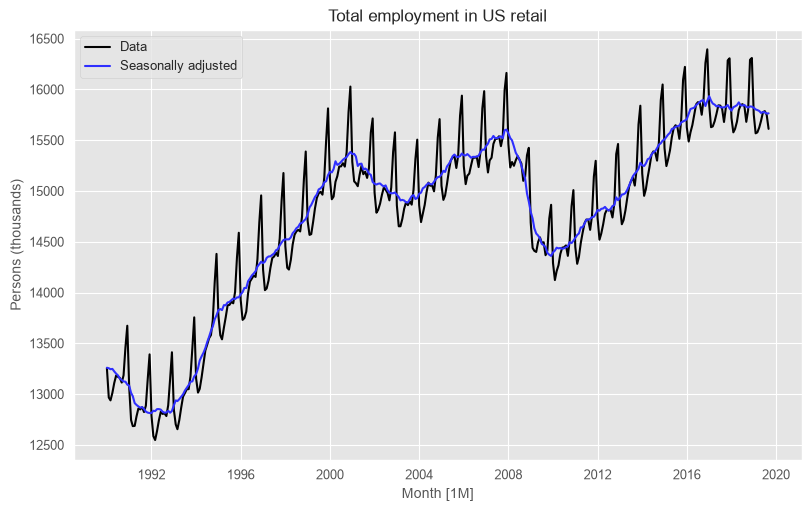

In [23]:
# Seasonally adjusted (in additive transformation)

df = dcmp.assign(adj=lambda x: x["data"] - x["seasonal"])
sns.lineplot(df, x="ds", y="data", label="Data")
sns.lineplot(df, x="ds", y="adj", label="Seasonally adjusted")
plt.title("Total employment in US retail")
plt.xlabel("Month [1M]")
plt.ylabel("Persons (thousands)")
plt.legend()

plt.show()

# Forecaster's Toolbox


In [24]:
gdp_df = pd.read_csv("data/global_economy.csv", parse_dates=["ds"])[
    ["unique_id", "ds", "GDP", "Population"]
].assign(
    GDP=lambda x: x["GDP"].interpolate(),
    Population=lambda x: x["Population"].interpolate(),
    y=lambda x: x["GDP"] / x["Population"],
)

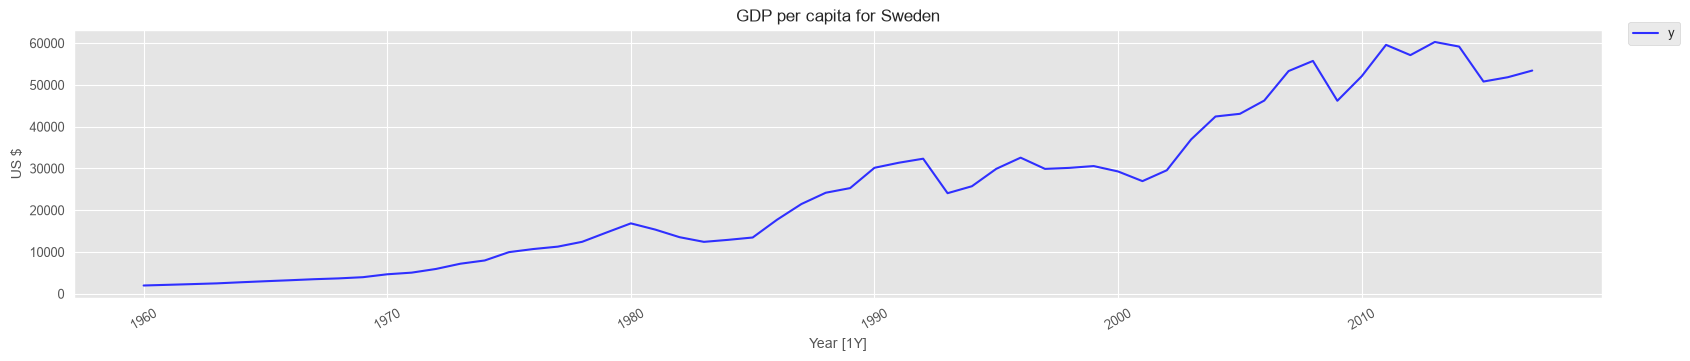

In [25]:
fig = plot_series(gdp_df, ids=["Sweden"])

ax = fig.axes[0]
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("US $")
ax.set_title("GDP per capita for Sweden")

fig

In [26]:
sweden_df = gdp_df[gdp_df["unique_id"] == "Sweden"]
sweden_df = sweden_df[["unique_id", "ds", "y"]]

print(len(sweden_df))
sweden_df.head()

58


,unique_id,ds,y
13324,Sweden,1960-01-01,1983.107
13325,Sweden,1961-01-01,2147.229
13326,Sweden,1962-01-01,2315.847
13327,Sweden,1963-01-01,2492.545
13328,Sweden,1964-01-01,2758.943


In [27]:
from utilsforecast.feature_engineering import pipeline, trend
from sklearn.linear_model import LinearRegression
from statsforecast.models import SklearnModel
from statsforecast import StatsForecast

train_feats, validation_feats = pipeline(sweden_df, features=[trend], freq="YE", h=10)
trend_model = SklearnModel(LinearRegression())
sf = StatsForecast(models=[trend_model], freq="YE")
sf.fit(train_feats)

StatsForecast(models=[LinearRegression])

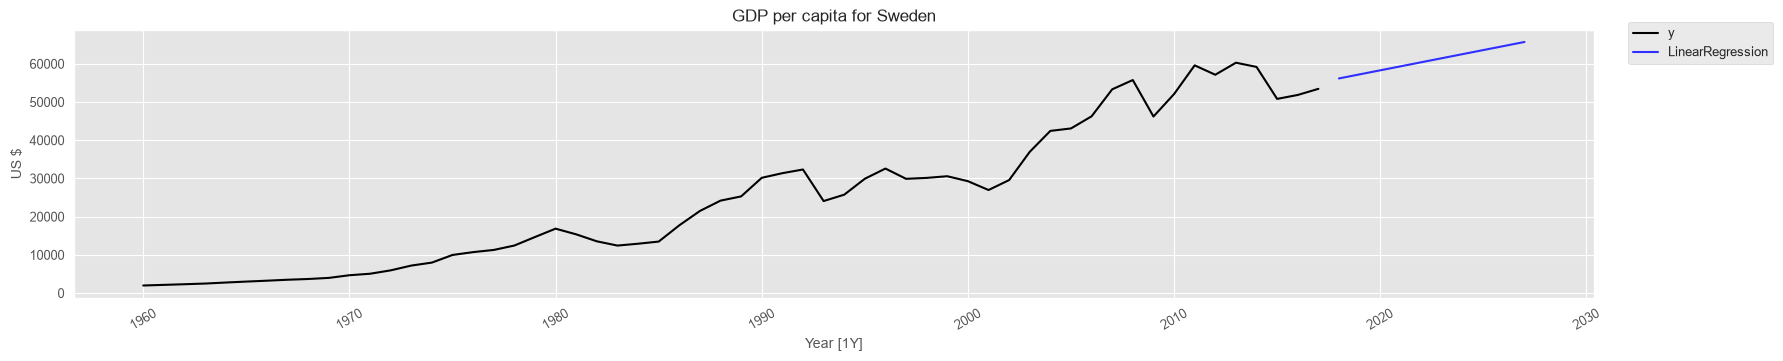

In [28]:
fcasts = sf.predict(h=10, X_df=validation_feats)

fig = plot_series(sweden_df, fcasts, ids=["Sweden"])

ax = fig.axes[0]
ax.set_xlabel("Year [1Y]")
ax.set_ylabel("US $")
ax.set_title("GDP per capita for Sweden")


fig

## Residual

A good forecasting method will yield innovation residuals with the following properties:

1. The innovation residuals are uncorrelated. If there are correlations between innovation residuals, then there is information left in the residuals which should be used in computing forecasts.
2. The innovation residuals have zero mean. If they have a mean other than zero, then the forecasts are biased.
3. The innovation residuals have constant variance. This is known as “homoscedasticity”.
4. The innovation residuals are normally distributed.


# Exponential Smoothing


## Simple Exponential smoothing


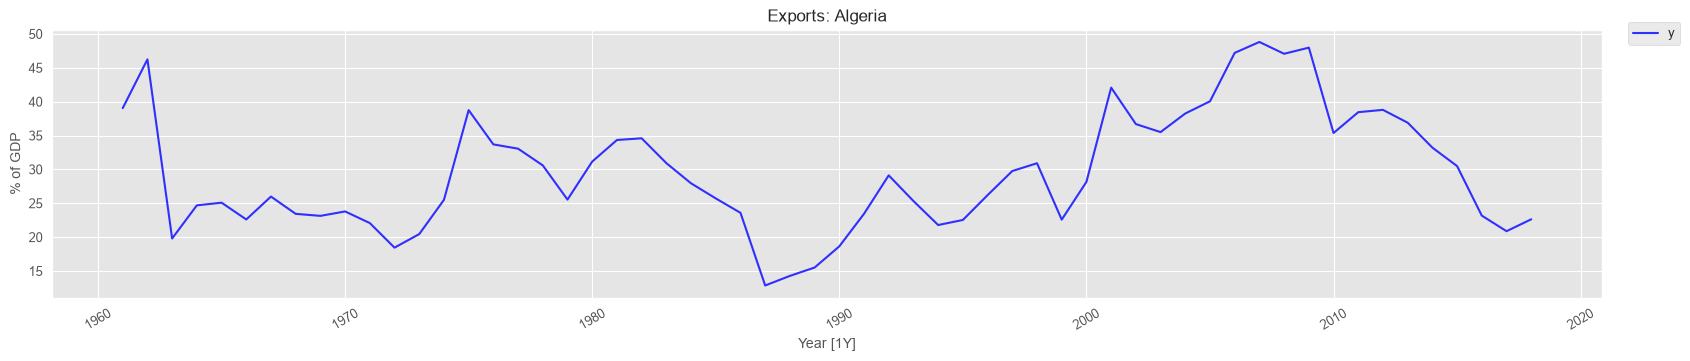

In [29]:
algeria_economy = pd.read_csv("data/algeria_exports.csv", parse_dates=["ds"])

fig = plot_series(algeria_economy)
ax = fig.axes[0]
ax.set_xlabel("Year [1Y]")
ax.set_ylabel(r"% of GDP")
ax.set_title("Exports: Algeria")

fig

In [30]:
from statsforecast.models import AutoETS

sf = StatsForecast(models=[AutoETS(model="ANN", alias="SimpleES")], freq="YE")
algeria_fcasts = sf.forecast(h=5, df=algeria_economy, level=[80, 95], fitted=True)
algeria_fcasts.head()

,unique_id,ds,SimpleES,SimpleES-lo-95,SimpleES-lo-80,SimpleES-hi-80,SimpleES-hi-95
0,Algeria,2018-12-31,22.442,10.523,14.648,30.235,34.361
1,Algeria,2019-12-31,22.442,6.875,12.263,32.620,38.009
2,Algeria,2020-12-31,22.442,3.933,10.339,34.544,40.951
3,Algeria,2021-12-31,22.442,1.398,8.682,36.202,43.486
4,Algeria,2022-12-31,22.442,-0.863,7.204,37.680,45.746


In [31]:
fitted_vals = sf.forecast_fitted_values()
fitted_vals.head()

,unique_id,ds,y,SimpleES,SimpleES-lo-95,SimpleES-lo-80,SimpleES-hi-80,SimpleES-hi-95
0,Algeria,1960-12-31,39.043,39.530,27.720,31.808,47.252,51.340
1,Algeria,1961-12-31,46.245,39.121,27.311,31.399,46.843,50.931
2,Algeria,1962-12-31,19.794,45.105,33.295,37.383,52.828,56.916
3,Algeria,1963-12-31,24.685,23.842,12.031,16.119,31.564,35.652
4,Algeria,1964-12-31,25.084,24.550,12.740,16.828,32.272,36.360


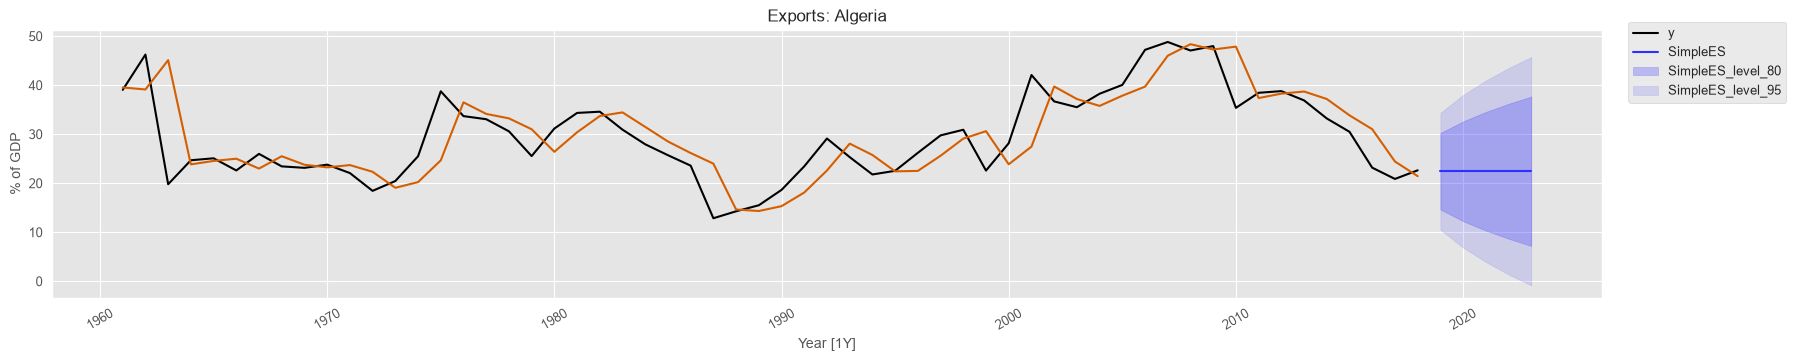

In [32]:
fig = plot_series(algeria_economy, algeria_fcasts, level=[80, 95])

ax = fig.axes[0]
ax.plot("ds", "SimpleES", data=fitted_vals, color="#D55E00")
ax.set_xlabel("Year [1Y]")
ax.set_ylabel(r"% of GDP")
ax.set_title("Exports: Algeria")

fig

In [33]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mape, mase, rmse
from functools import partial

cv = sf.cross_validation(df=algeria_economy, h=1, step_size=1, test_size=10)

evaluation = evaluate(
    cv,
    metrics=[mae, rmse, mape, partial(mase, seasonality=1)],
    train_df=algeria_economy,
)

summary = evaluation.groupby("metric", as_index=False)[["SimpleES"]].mean()

summary

,metric,SimpleES
0,mae,3.639
1,mape,0.125
2,mase,0.866
3,rmse,3.639


## Holt's Linear


Optimal parameters:
alpha: 0.9999
beta: 0.0001
Initial level: 1019.4209
Initial trend: 899.4189


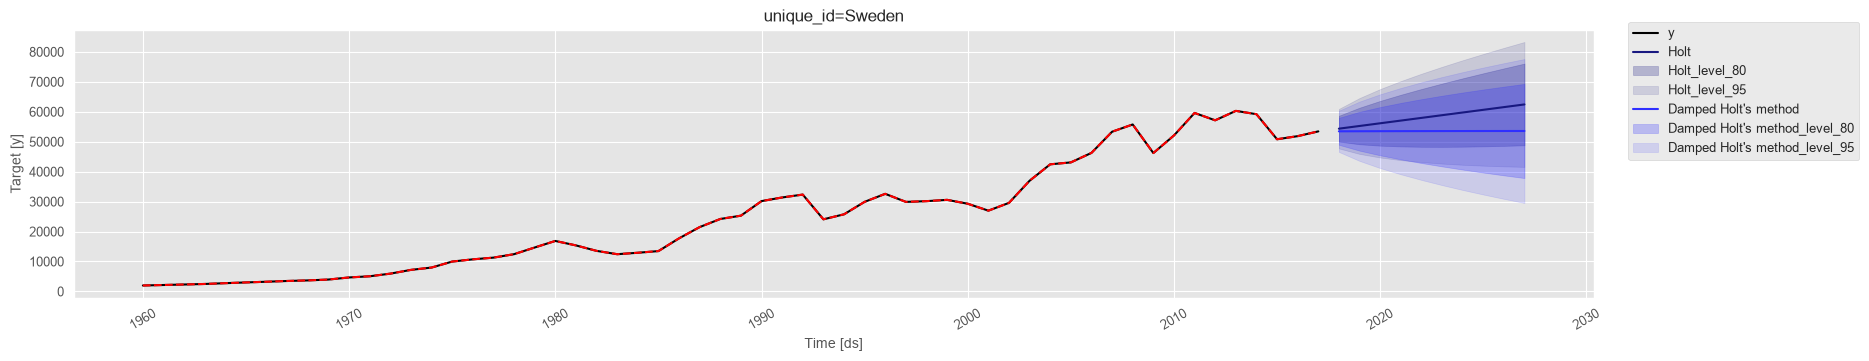

In [34]:
sf = StatsForecast(
    models=[
        AutoETS(model="AAN", alias="Holt"),
        AutoETS(model="AAN", alias="Damped Holt's method", damped=True, phi=0.9),
    ],
    freq="YE",
)
fc = sf.fit_predict(df=train_feats.drop(columns=["trend"]), h=10, level=[80, 95])

params = np.round(sf.fitted_[0, 0].model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

fig = plot_series(train_feats.drop(columns=["trend"]), fc, level=[80, 95])

ax = fig.axes[0]
ax.plot("ds", "y", "r--", data=train_feats)

fig

## Holt Winters


Optimal parameters:
alpha: 0.514
beta: 0.001
Initial level: 0.0033
Initial trend: -2192.66


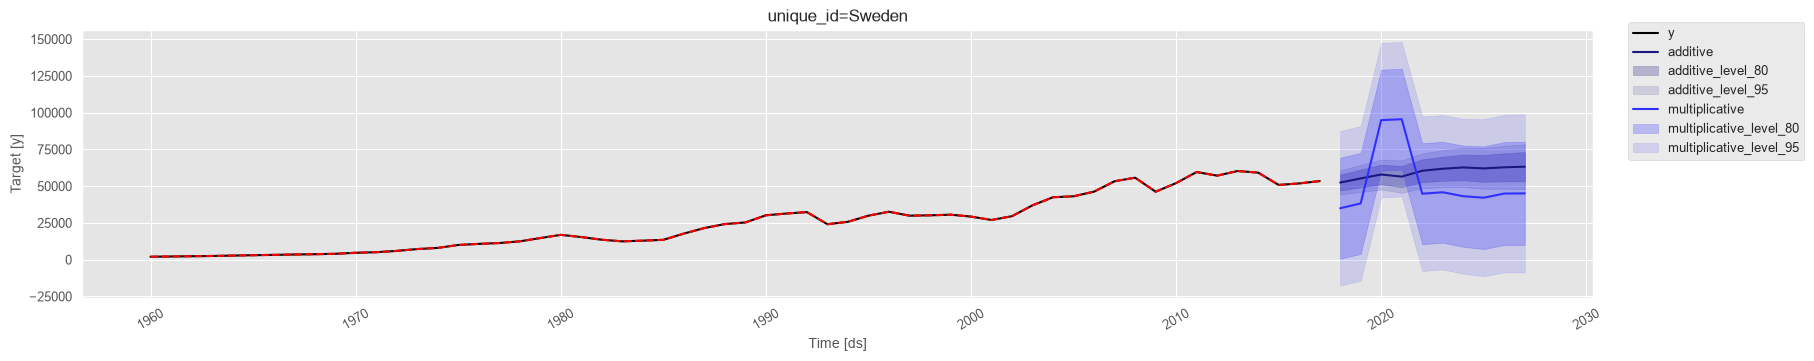

In [35]:
sf = StatsForecast(
    models=[
        AutoETS(season_length=12, model="AAA", alias="additive"),
        AutoETS(season_length=12, model="MAM", alias="multiplicative"),
    ],
    freq="YE",
)
fc = sf.fit_predict(df=train_feats.drop(columns=["trend"]), h=10, level=[80, 95])

params = np.round(sf.fitted_[0, 0].model_["fit"].x, 4)
print("Optimal parameters:")
print("alpha:", params[0])
print("beta:", params[1])
print("Initial level:", params[2])
print("Initial trend:", params[3])

fig = plot_series(train_feats.drop(columns=["trend"]), fc, level=[80, 95])

ax = fig.axes[0]
ax.plot("ds", "y", "r--", data=train_feats)

fig

In [36]:
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mae, mape, mase, rmse
from functools import partial

evaluation = evaluate(
    fc.assign(y=fc["additive"]),
    metrics=[mae, mape, partial(mase, seasonality=12), rmse],
    train_df=train_feats,
)

evaluation

,unique_id,metric,additive,multiplicative
0,Sweden,mae,0.0,21760.172
1,Sweden,mape,0.0,0.369
2,Sweden,mase,0.0,1.646
3,Sweden,rmse,0.0,23266.626


# ACF & PACF

| Model       | ACF                   | PACF                  |
| ----------- | --------------------- | --------------------- |
| White Noise | No significant spikes | No significant spikes |
| AR(1)       | Gradual decay         | Cuts off after lag 1  |
| AR(2)       | Gradual decay         | Cuts off after lag 2  |
| MA(1)       | Cuts off after lag 1  | Gradual decay         |
| MA(2)       | Cuts off after lag 2  | Gradual decay         |


# ARIMA


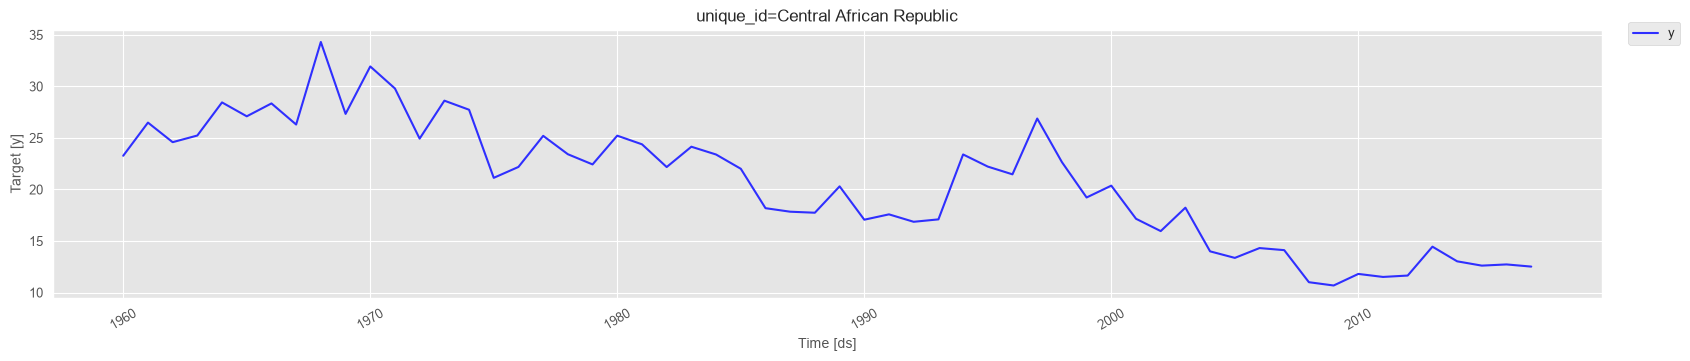

In [37]:
caf_economy = (
    pd.read_csv("data/global_economy.csv", parse_dates=[2])
    .rename(columns={"Exports": "y"})
    .loc[lambda x: x["Code"] == "CAF"][["unique_id", "ds", "y"]]
)

plot_series(caf_economy)

C:\Users\USER\AppData\Local\Temp\ipykernel_13920\258318865.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


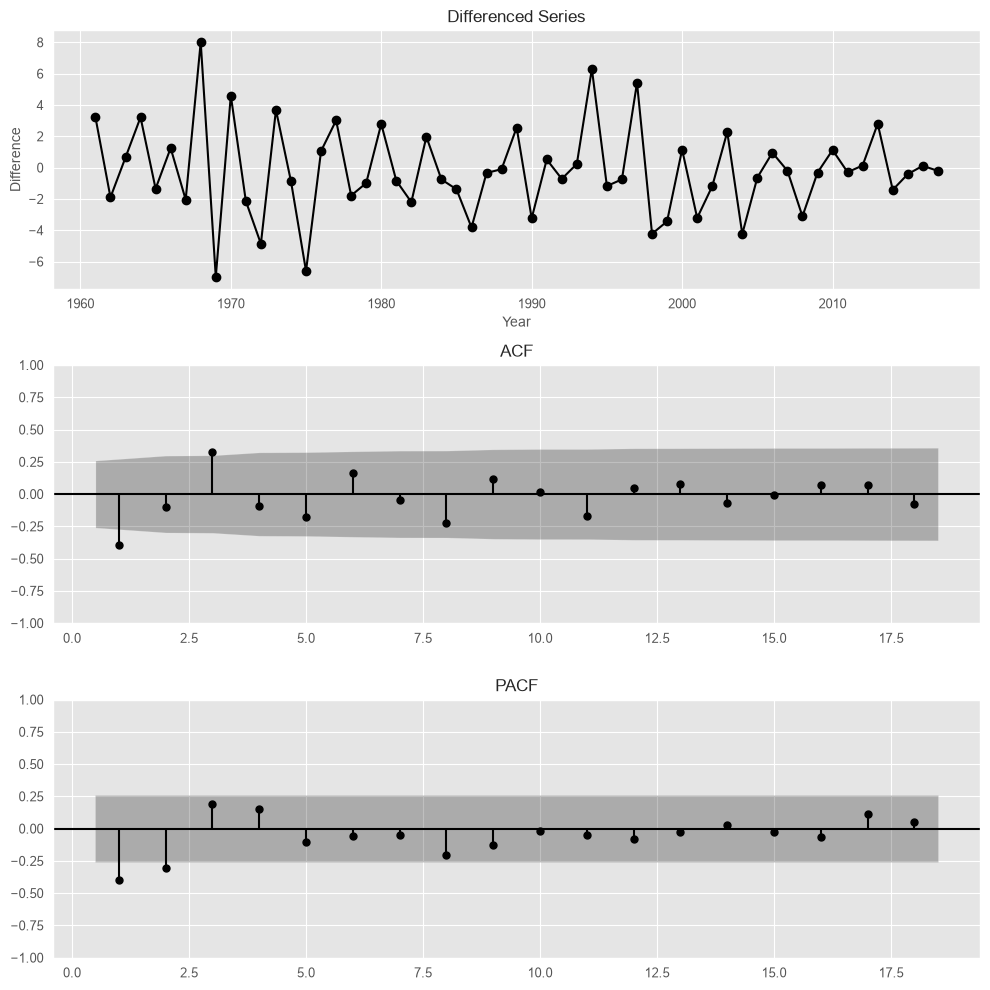

In [38]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# First difference the series
df = caf_economy.copy()
df["diff"] = df["y"].diff()
df = df.dropna()

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Differenced series
axes[0].plot(df["ds"], df["diff"], marker="o")
axes[0].set_title("Differenced Series")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Difference")

# ACF plot
plot_acf(df["diff"], ax=axes[1], zero=False)
axes[1].set_title("ACF")

# PACF plot
plot_pacf(df["diff"], ax=axes[2], zero=False)
axes[2].set_title("PACF")

plt.tight_layout()
plt.show()

# Review


In [39]:
raw_data = sales_data = {
    "date": [
        "2022-01-01",
        "2022-02-01",
        "2022-03-01",
        "2022-04-01",
        "2022-05-01",
        "2022-06-01",
        "2022-07-01",
        "2022-08-01",
        "2022-09-01",
        "2022-10-01",
        "2022-11-01",
        "2022-12-01",
        "2023-01-01",
        "2023-02-01",
        "2023-03-01",
        "2023-04-01",
        "2023-05-01",
        "2023-06-01",
        "2023-07-01",
        "2023-08-01",
        "2023-09-01",
        "2023-10-01",
        "2023-11-01",
        "2023-12-01",
        "2024-01-01",
        "2024-02-01",
        "2024-03-01",
        "2024-04-01",
        "2024-05-01",
        "2024-06-01",
        "2024-07-01",
        "2024-08-01",
        "2024-09-01",
        "2024-10-01",
        "2024-11-01",
        "2024-12-01",
        "2025-01-01",
        "2025-02-01",
        "2025-03-01",
        "2025-04-01",
        "2025-05-01",
        "2025-06-01",
        "2025-07-01",
        "2025-08-01",
        "2025-09-01",
        "2025-10-01",
        "2025-11-01",
        "2025-12-01",
    ],
    "sales": [
        120,
        128,
        135,
        142,
        150,
        160,
        168,
        165,
        158,
        175,
        195,
        230,
        130,
        138,
        146,
        154,
        164,
        175,
        183,
        180,
        172,
        190,
        212,
        250,
        142,
        150,
        158,
        168,
        178,
        190,
        200,
        196,
        188,
        207,
        230,
        272,
        155,
        163,
        172,
        182,
        194,
        207,
        218,
        214,
        205,
        226,
        252,
        295,
    ],
}
data = pd.DataFrame(raw_data)

In [40]:
data.head()

,date,sales
0,2022-01-01,120
1,2022-02-01,128
2,2022-03-01,135
3,2022-04-01,142
4,2022-05-01,150


In [41]:
data = data.assign(ds=data.date, y=data.sales).drop(columns=["date", "sales"])
data.head()

,ds,y
0,2022-01-01,120
1,2022-02-01,128
2,2022-03-01,135
3,2022-04-01,142
4,2022-05-01,150


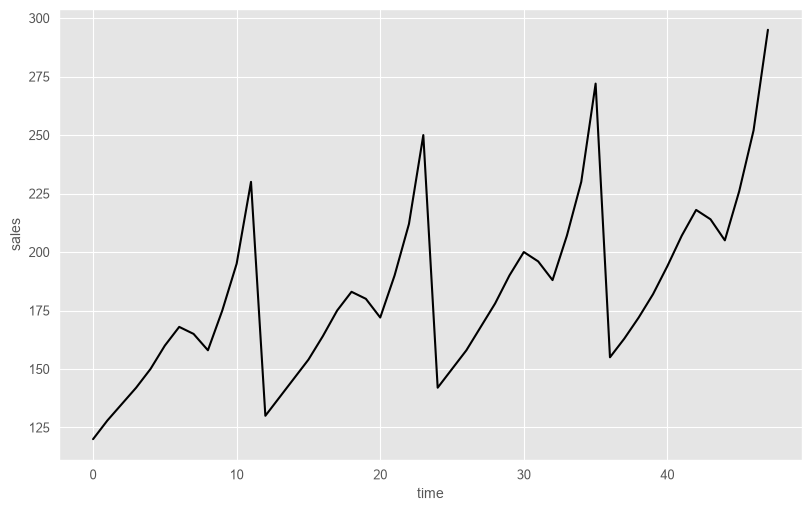

In [42]:
import matplotlib.pyplot as plt

plt.plot(data.y)
plt.xlabel("time")
plt.ylabel("sales")
plt.show()

In [43]:
data["ds"] = pd.to_datetime(data.ds)
data.head()

,ds,y
0,2022-01-01,120
1,2022-02-01,128
2,2022-03-01,135
3,2022-04-01,142
4,2022-05-01,150


In [44]:
data["y"].rolling(3).mean().dropna()

2     127.667
3     135.000
4     142.333
5     150.667
6     159.333
7     164.333
8     163.667
9     166.000
10    176.000
11    200.000
12    185.000
13    166.000
14    138.000
15    146.000
16    154.667
17    164.333
18    174.000
19    179.333
20    178.333
21    180.667
22    191.333
23    217.333
24    201.333
25    180.667
26    150.000
27    158.667
28    168.000
29    178.667
30    189.333
31    195.333
32    194.667
33    197.000
34    208.333
35    236.333
36    219.000
37    196.667
38    163.333
39    172.333
40    182.667
41    194.333
42    206.333
43    213.000
44    212.333
45    215.000
46    227.667
47    257.667
Name: y, dtype: float64

In [45]:
data.head()

,ds,y
0,2022-01-01,120
1,2022-02-01,128
2,2022-03-01,135
3,2022-04-01,142
4,2022-05-01,150


In [46]:
data["month"] = data.ds.dt.month_name()

data.groupby(["month"])["y"].mean()

month
April        161.50
August       188.75
December     261.75
February     144.75
January      136.75
July         192.25
June         183.00
March        152.75
May          171.50
November     222.25
October      199.50
September    180.75
Name: y, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_13920\2984000320.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


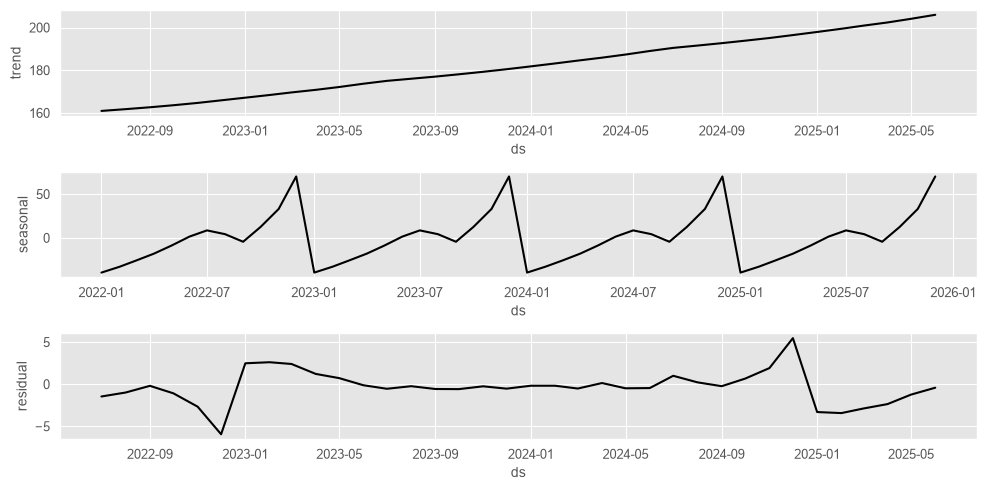

In [47]:
from statsmodels.tsa.seasonal import seasonal_decompose

dcmp = seasonal_decompose(data.y, model="additive", period=12)

dcmp_df = pd.DataFrame(
    {
        "ds": data.ds,
        "y": data.y,
        "trend": dcmp.trend,
        "seasonal": dcmp.seasonal,
        "residual": dcmp.resid,
    }
)

plt.figure(figsize=(10, 5))

plt.subplot(311)
sns.lineplot(data=dcmp_df, x="ds", y="trend")
plt.subplot(312)
sns.lineplot(data=dcmp_df, x="ds", y="seasonal")
plt.subplot(313)
sns.lineplot(data=dcmp_df, x="ds", y="residual")

plt.tight_layout()
plt.show()

# Prophet


In [48]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

In [49]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)
df.head()

,ds,y
0,2007-12-10,9.591
1,2007-12-11,8.520
2,2007-12-12,8.184
3,2007-12-13,8.072
4,2007-12-14,7.894


In [50]:
m = Prophet()
m.fit(df)

17:07:00 - cmdstanpy - INFO - Chain [1] start processing
17:07:00 - cmdstanpy - INFO - Chain [1] done processing


In [51]:
future = m.make_future_dataframe(periods=365)
future.tail()

,ds
3265,2017-01-15
3266,2017-01-16
3267,2017-01-17
3268,2017-01-18
3269,2017-01-19


In [52]:
forecast = m.predict(future)
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

,ds,yhat,yhat_lower,yhat_upper
3265,2017-01-15,8.207,7.498,8.942
3266,2017-01-16,8.532,7.792,9.283
3267,2017-01-17,8.319,7.544,9.067
3268,2017-01-18,8.152,7.422,8.829
3269,2017-01-19,8.164,7.452,8.862


c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:95: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


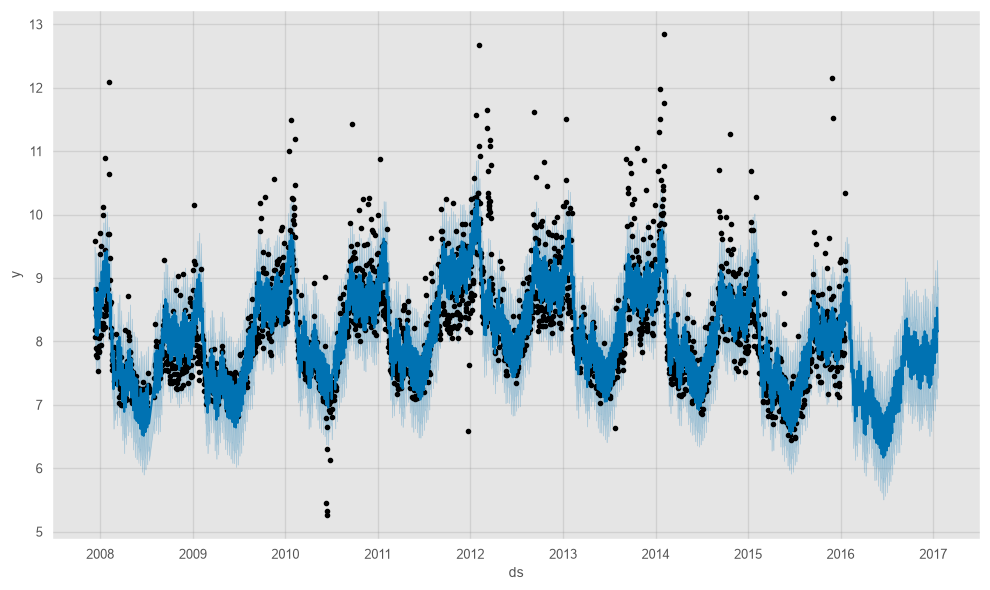

In [53]:
fig = m.plot(forecast)

c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


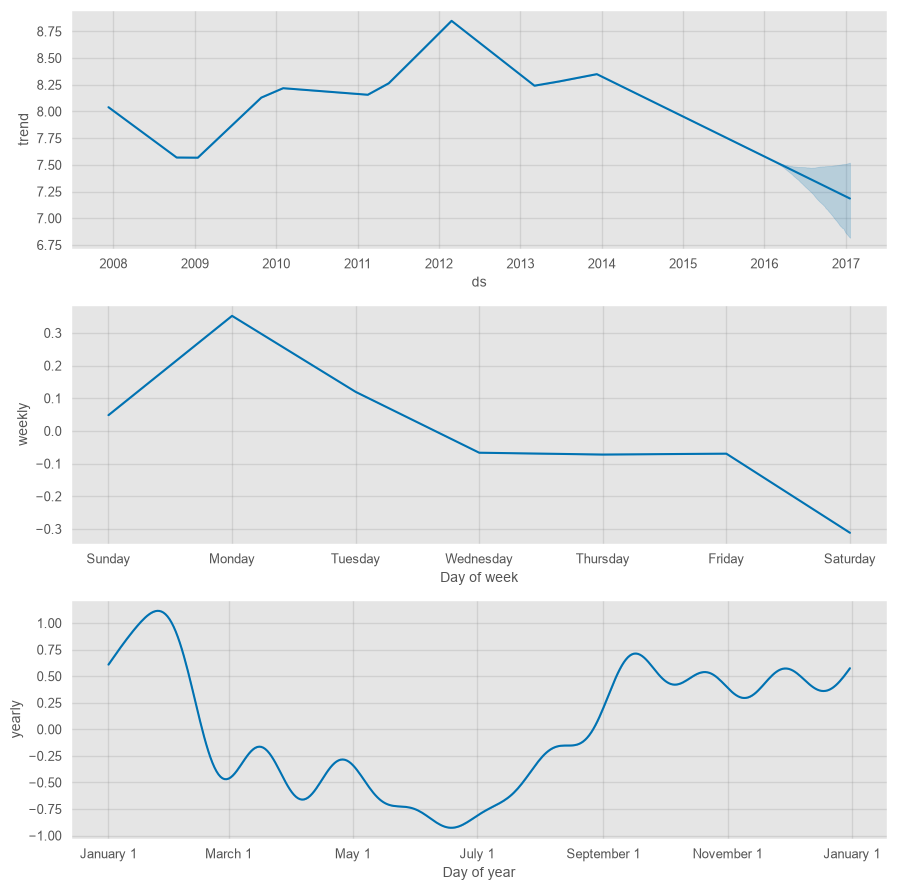

In [54]:
m.plot_components(forecast)
plt.show()

In [55]:
from prophet.plot import plot_plotly, plot_components_plotly

plot_plotly(m, forecast)

In [56]:
plot_components_plotly(m, forecast)

## Saturating Forecast


In [57]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_wp_log_peyton_manning.csv"
)
df.head()

,ds,y
0,2007-12-10,9.591
1,2007-12-11,8.520
2,2007-12-12,8.184
3,2007-12-13,8.072
4,2007-12-14,7.894


In [58]:
df["cap"] = 8.5
df["floor"] = 1.5
m = Prophet(growth="logistic")
m.fit(df)

17:07:04 - cmdstanpy - INFO - Chain [1] start processing
17:07:05 - cmdstanpy - INFO - Chain [1] done processing


c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:95: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


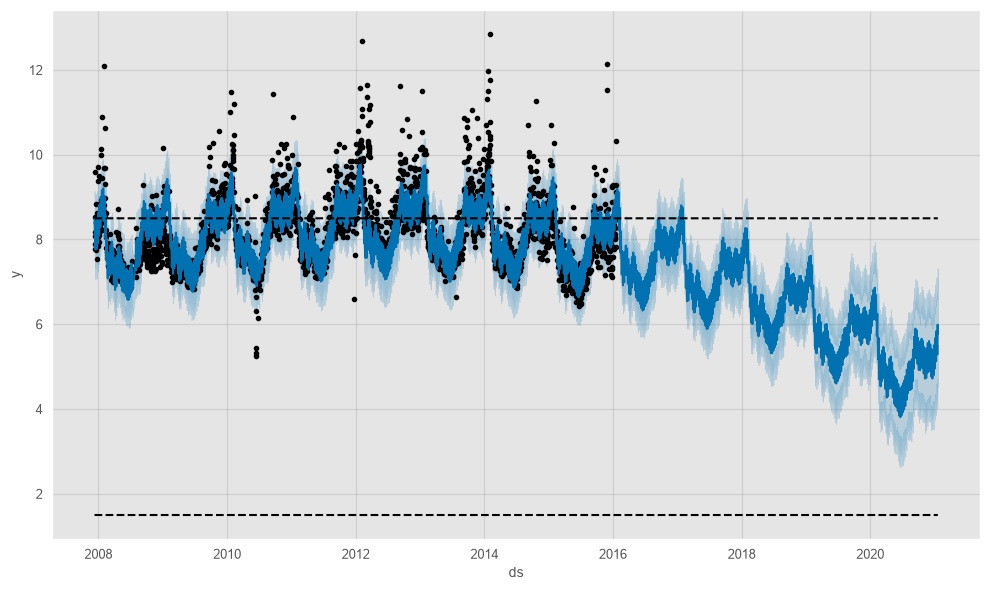

In [59]:
future = m.make_future_dataframe(periods=1826)
future["cap"] = 8.5
future["floor"] = 1.5
fcst = m.predict(future)
m.plot(fcst)
plt.show()

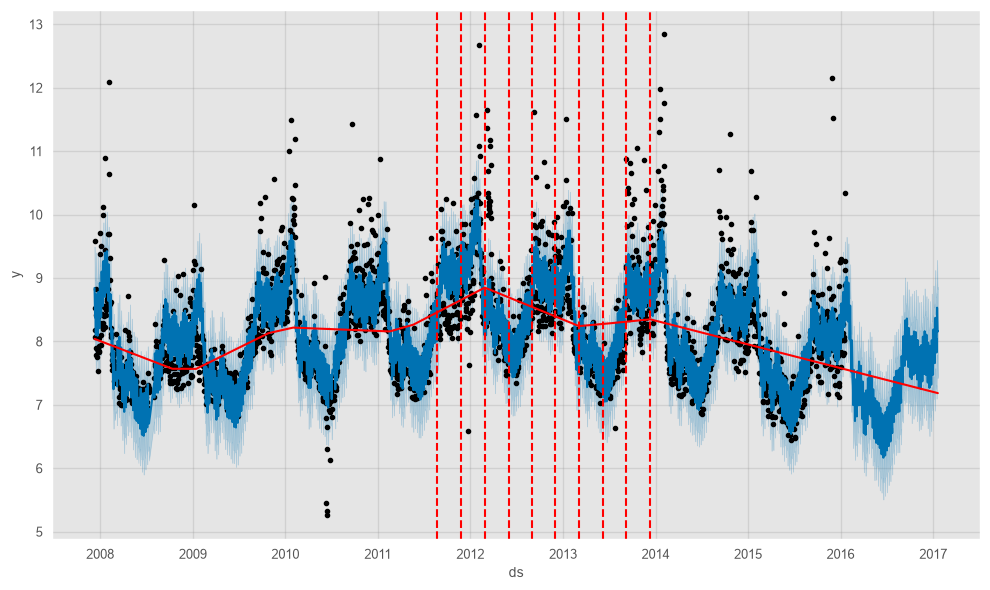

In [60]:
from prophet.plot import add_changepoints_to_plot

a = add_changepoints_to_plot(fig.gca(), m, forecast)
fig

## Seasonality, Holidays and Regressors


In [61]:
playoffs = pd.DataFrame(
    {
        "holiday": "playoff",
        "ds": pd.to_datetime(
            [
                "2008-01-13",
                "2009-01-03",
                "2010-01-16",
                "2010-01-24",
                "2010-02-07",
                "2011-01-08",
                "2013-01-12",
                "2014-01-12",
                "2014-01-19",
                "2014-02-02",
                "2015-01-11",
                "2016-01-17",
                "2016-01-24",
                "2016-02-07",
            ]
        ),
        "lower_window": 0,
        "upper_window": 1,
    }
)

superbowls = pd.DataFrame(
    {
        "holiday": "superbowl",
        "ds": pd.to_datetime(["2010-02-07", "2014-02-02", "2016-02-07"]),
        "lower_window": 0,
        "upper_window": 1,
    }
)
holidays = pd.concat((playoffs, superbowls))

holidays

,holiday,ds,lower_window,upper_window
0,playoff,2008-01-13,0,1
1,playoff,2009-01-03,0,1
2,playoff,2010-01-16,0,1
3,playoff,2010-01-24,0,1
4,playoff,2010-02-07,0,1
5,playoff,2011-01-08,0,1
6,playoff,2013-01-12,0,1
7,playoff,2014-01-12,0,1
8,playoff,2014-01-19,0,1
9,playoff,2014-02-02,0,1


In [62]:
m = Prophet(holidays=holidays)
forecast = m.fit(df).predict(future)
forecast.head()

17:07:21 - cmdstanpy - INFO - Chain [1] start processing
17:07:22 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,cap,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2007-12-10,8.047,8.5,8.233,9.418,8.047,8.047,0.796,0.796,0.796,...,0.330,0.330,0.330,0.467,0.467,0.467,0.0,0.0,0.0,8.843
1,2007-12-11,8.045,8.5,8.054,9.242,8.045,8.045,0.585,0.585,0.585,...,0.133,0.133,0.133,0.452,0.452,0.452,0.0,0.0,0.0,8.630
2,2007-12-12,8.043,8.5,7.836,9.050,8.043,8.043,0.386,0.386,0.386,...,-0.053,-0.053,-0.053,0.439,0.439,0.439,0.0,0.0,0.0,8.429
3,2007-12-13,8.042,8.5,7.829,8.987,8.042,8.042,0.368,0.368,0.368,...,-0.059,-0.059,-0.059,0.427,0.427,0.427,0.0,0.0,0.0,8.409
4,2007-12-14,8.040,8.5,7.828,9.016,8.040,8.040,0.360,0.360,0.360,...,-0.056,-0.056,-0.056,0.416,0.416,0.416,0.0,0.0,0.0,8.400


In [63]:
forecast[(forecast["playoff"] + forecast["superbowl"]).abs() != 0][
    ["ds", "playoff", "superbowl"]
]

,ds,playoff,superbowl
34,2008-01-13,1.228,0.000
35,2008-01-14,1.902,0.000
361,2009-01-03,1.228,0.000
362,2009-01-04,1.902,0.000
730,2010-01-16,1.228,0.000
731,2010-01-17,1.902,0.000
737,2010-01-25,1.902,0.000
750,2010-02-07,1.228,1.201
1076,2011-01-08,1.228,0.000
1077,2011-01-09,1.902,0.000


c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


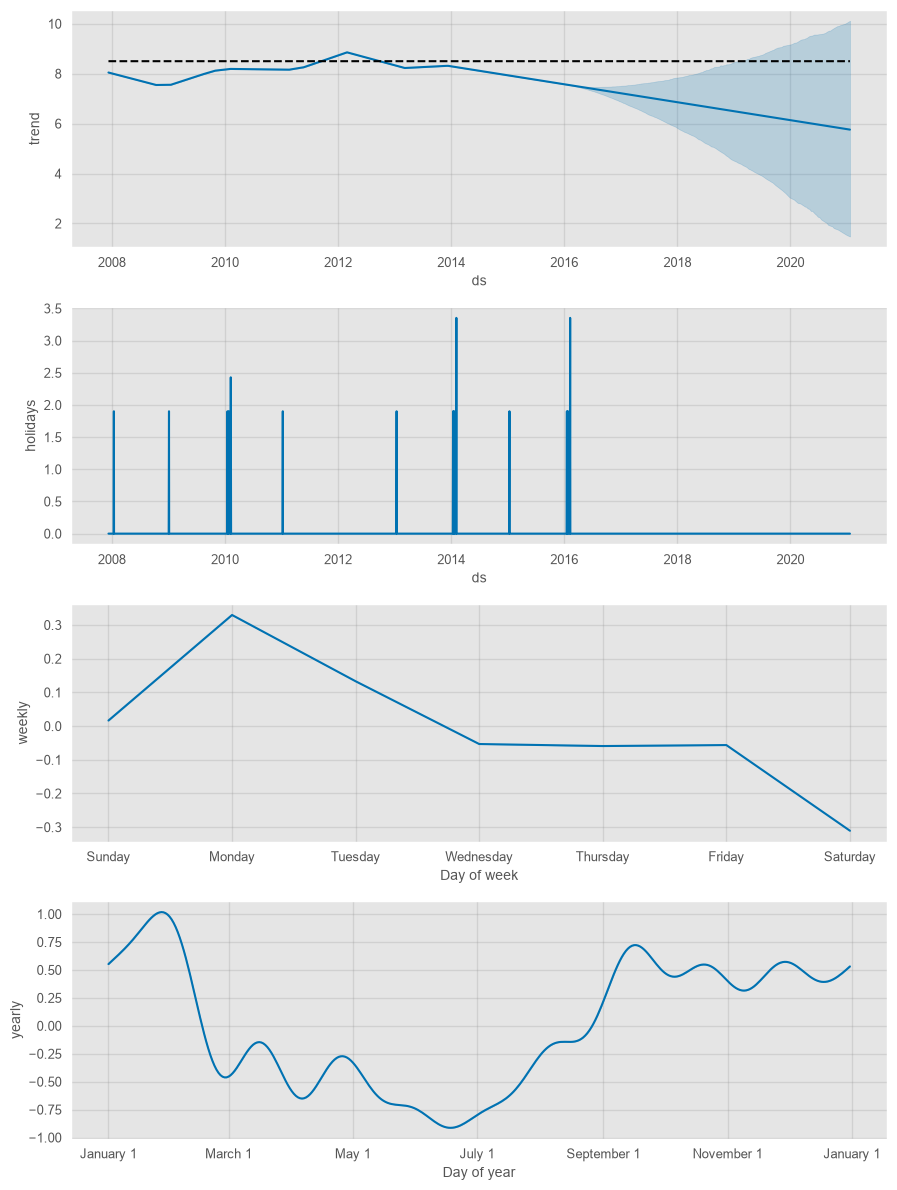

In [64]:
fig = m.plot_components(forecast)

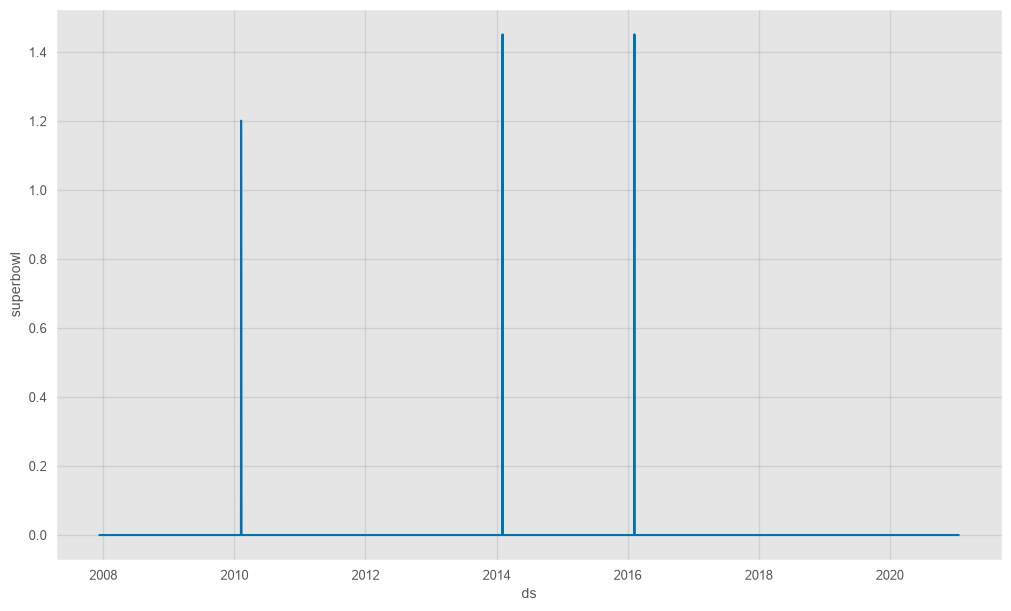

In [65]:
from prophet.plot import plot_forecast_component

fig = plot_forecast_component(m, forecast, "superbowl")

In [66]:
m = Prophet(holidays=holidays)
m.add_country_holidays(country_name="US")
m.fit(df)
m.train_holiday_names

17:07:23 - cmdstanpy - INFO - Chain [1] start processing
17:07:24 - cmdstanpy - INFO - Chain [1] done processing


0                         playoff
1                       superbowl
2                  New Year's Day
3                    Memorial Day
4                Independence Day
5                       Labor Day
6                Thanksgiving Day
7                   Christmas Day
8        Christmas Day (observed)
9      Martin Luther King Jr. Day
10          Washington's Birthday
11                   Columbus Day
12                   Veterans Day
13        Veterans Day (observed)
14    Independence Day (observed)
15      New Year's Day (observed)
dtype: object

In [67]:
m = Prophet(yearly_seasonality=20, holidays=holidays).fit(df)
forecast = m.predict(future)
plot_components_plotly(m, forecast)

17:07:24 - cmdstanpy - INFO - Chain [1] start processing
17:07:24 - cmdstanpy - INFO - Chain [1] done processing


17:07:25 - cmdstanpy - INFO - Chain [1] start processing
17:07:26 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


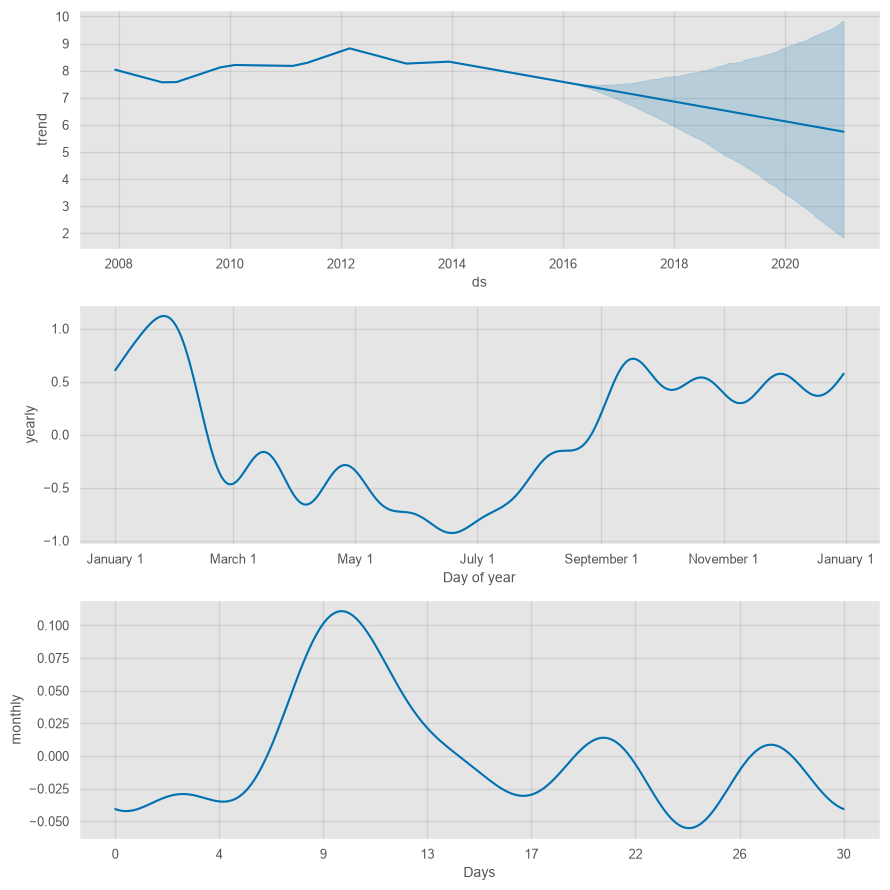

In [68]:
m = Prophet(weekly_seasonality=False)
m.add_seasonality("monthly", period=30.5, fourier_order=5)
m.fit(df)
future = m.make_future_dataframe(1826)
forecast = m.predict(future)
fig = m.plot_components(forecast)

In [69]:
def is_season(ds):
    ds = pd.to_datetime(ds)
    return ds.month > 8 or ds.month < 2


df["on_season"] = df.ds.apply(is_season)
df["off_season"] = ~df["on_season"]

future["on_season"] = future.ds.apply(is_season)
future["off_season"] = ~future["on_season"]

17:07:28 - cmdstanpy - INFO - Chain [1] start processing
17:07:28 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


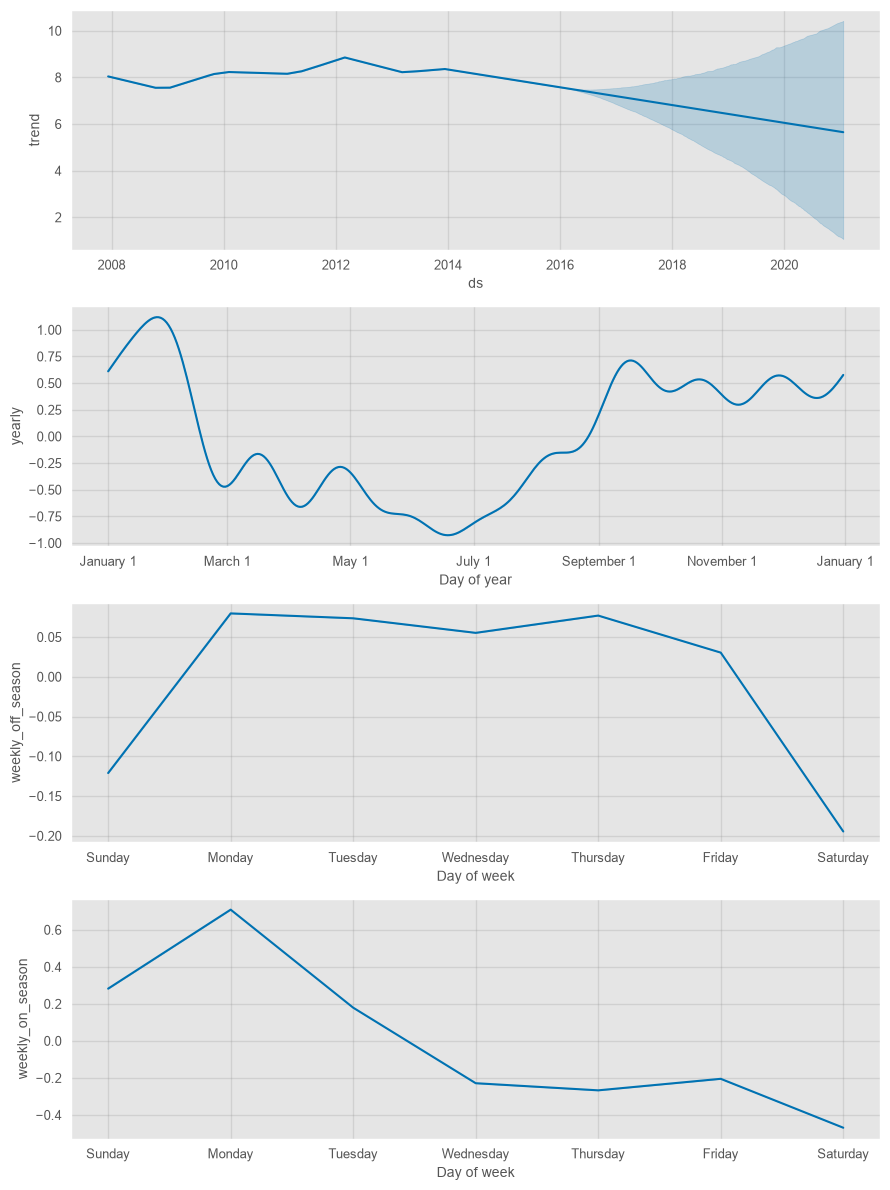

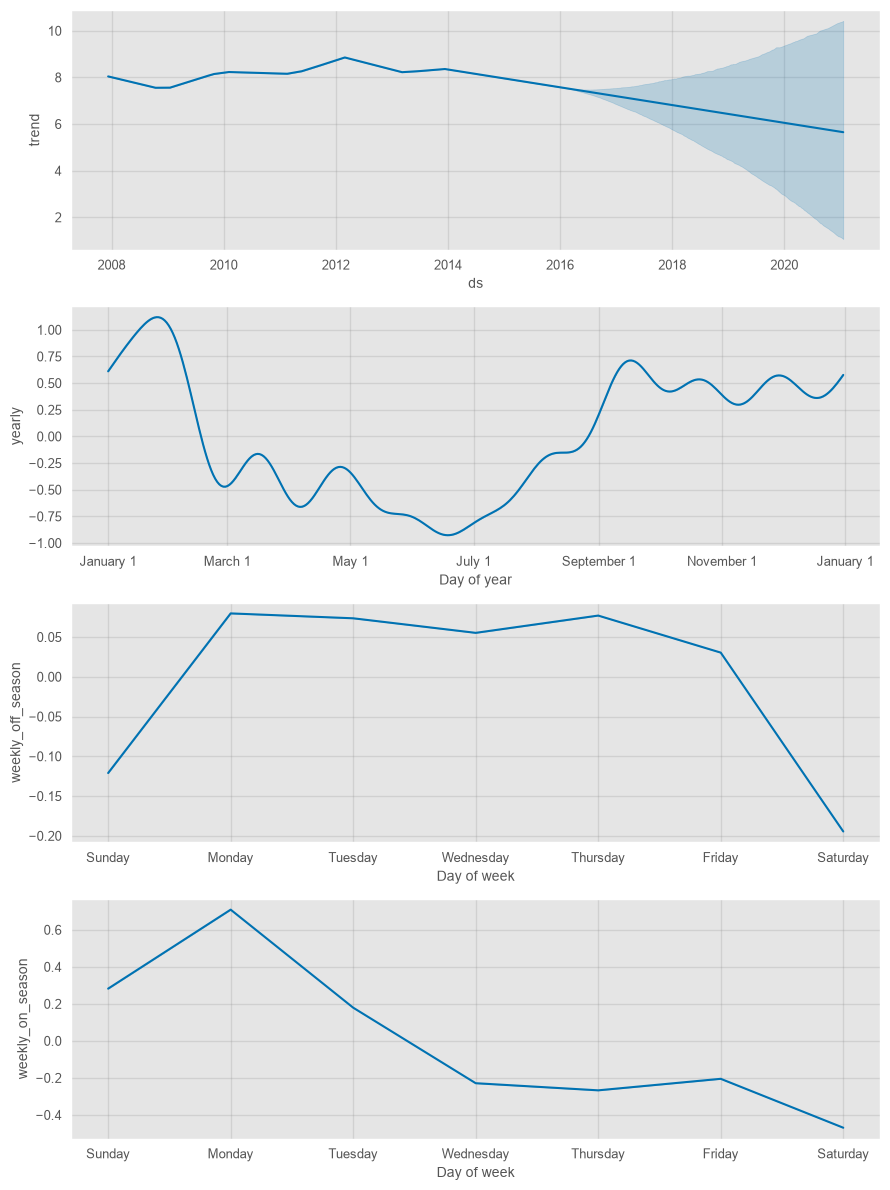

In [70]:
m = Prophet(weekly_seasonality=False)
m.add_seasonality(
    name="weekly_on_season", period=7, fourier_order=3, condition_name="on_season"
)
m.add_seasonality(
    name="weekly_off_season", period=7, fourier_order=3, condition_name="off_season"
)
m.fit(df)

forecast = m.predict(future)
m.plot_components(forecast)

17:07:30 - cmdstanpy - INFO - Chain [1] start processing
17:07:31 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


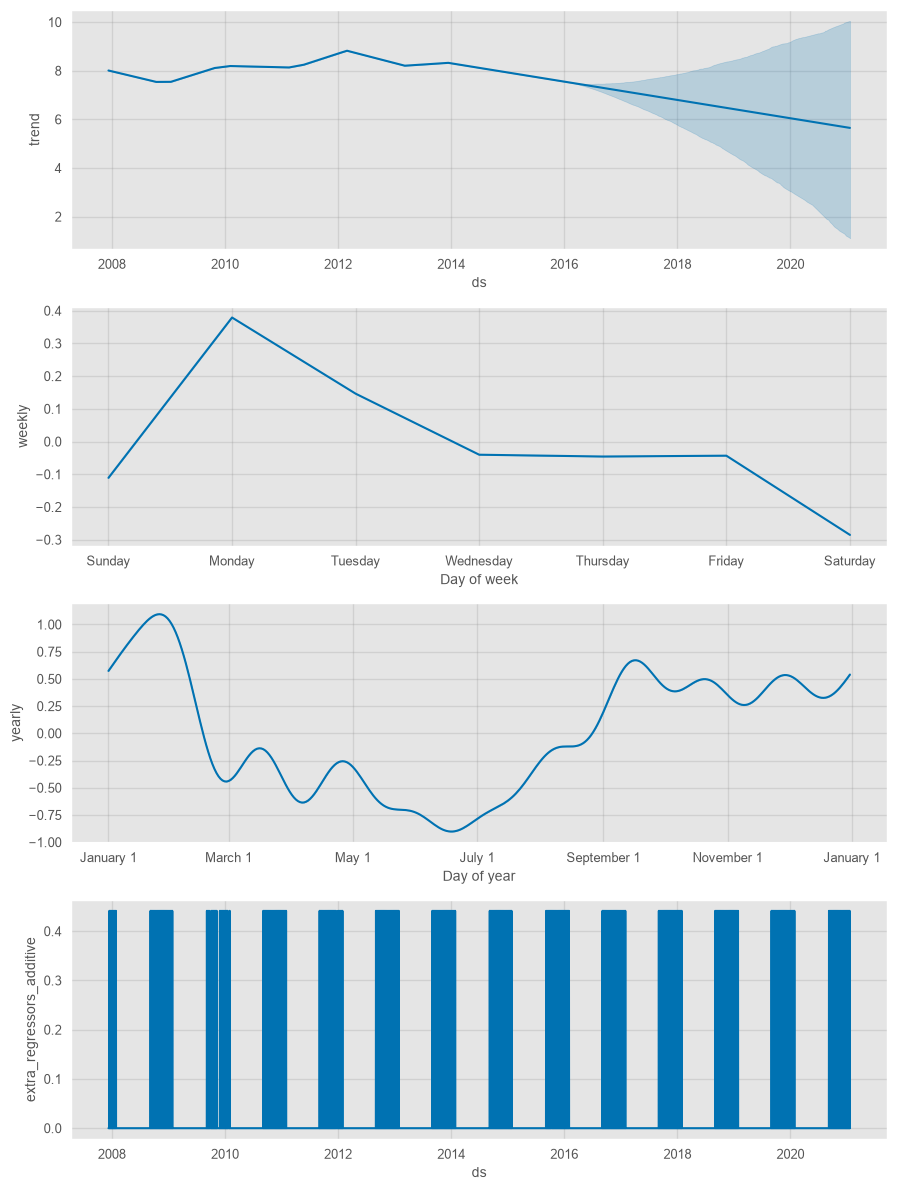

In [71]:
def season_sunday(ds):
    ds = pd.to_datetime(ds)
    return ds.weekday() == 6 and (ds.month > 8 or ds.month < 2)


df["season_sunday"] = df.ds.apply(season_sunday)

m = Prophet()
m.add_regressor("season_sunday")
m.fit(df)

future = m.make_future_dataframe(1826)
future["season_sunday"] = future.ds.apply(season_sunday)
forecast = m.predict(future)
fig = m.plot_components(forecast)

In [72]:
from prophet.utilities import regressor_coefficients

regressor_coefficients(m)

,regressor,regressor_mode,center,coef_lower,coef,coef_upper
0,season_sunday,additive,0.0,0.441,0.441,0.441


## Multiplicative Seasonality


,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


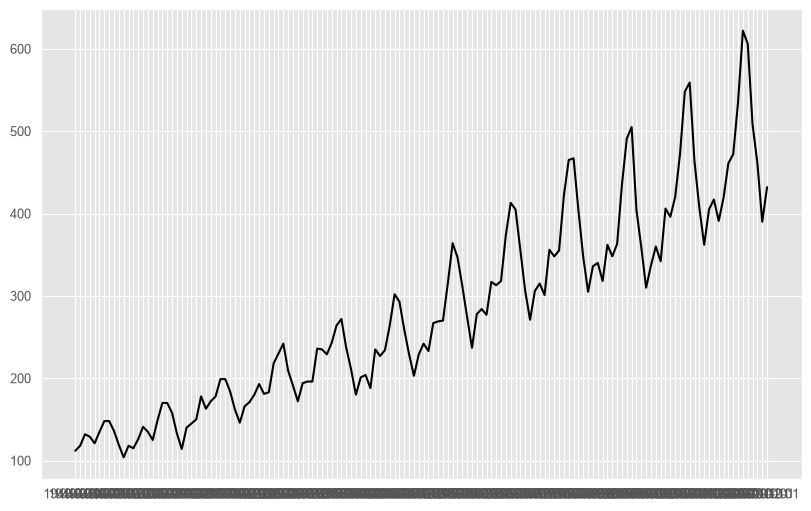

In [73]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/facebook/prophet/main/examples/example_air_passengers.csv"
)
display(df.head())

plt.plot(df["ds"], df["y"])
plt.show()

In this time series, the seasonality is not a constant additive factor as assumed by Prophet, rather it grows with the trend. This is multiplicative seasonality.


17:07:33 - cmdstanpy - INFO - Chain [1] start processing
17:07:33 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:95: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


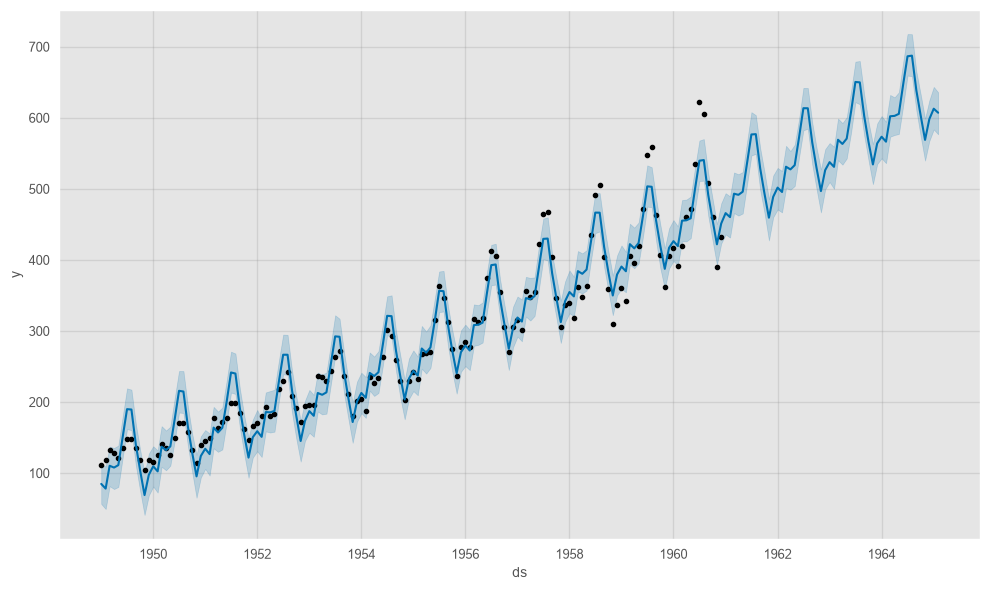

In [74]:
m = Prophet()
m.fit(df)
future = m.make_future_dataframe(50, freq="MS")
forecast = m.predict(future)
fig = m.plot(forecast)

But, as you can see when we use the additive seasonality the megaphone effect is lost. So we have to use the multiplicative mode


17:07:33 - cmdstanpy - INFO - Chain [1] start processing
17:07:33 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:95: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


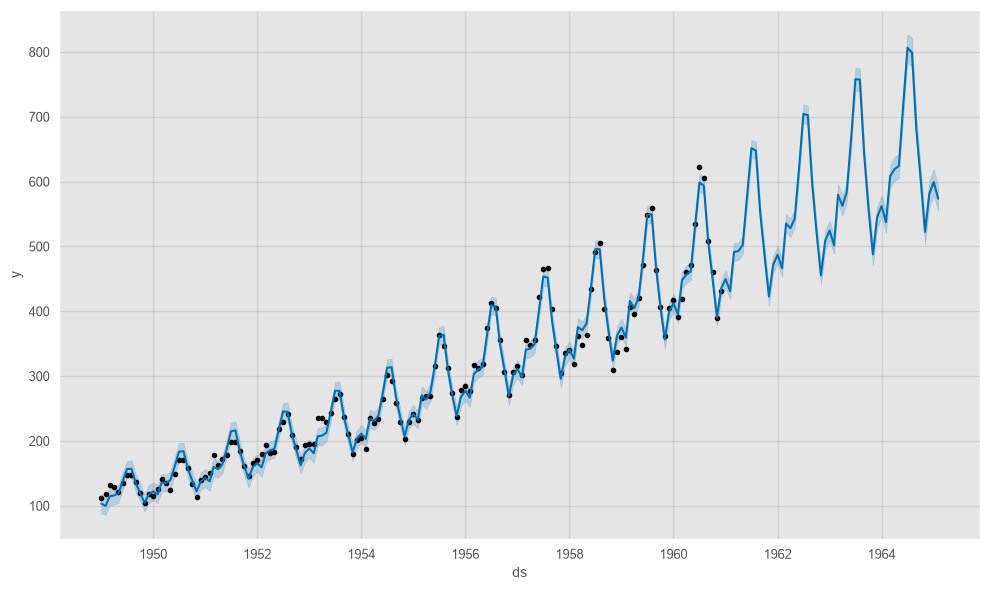

In [75]:
m = Prophet(seasonality_mode="multiplicative")
m.fit(df)
forecast = m.predict(future)
fig = m.plot(forecast)

c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:197: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


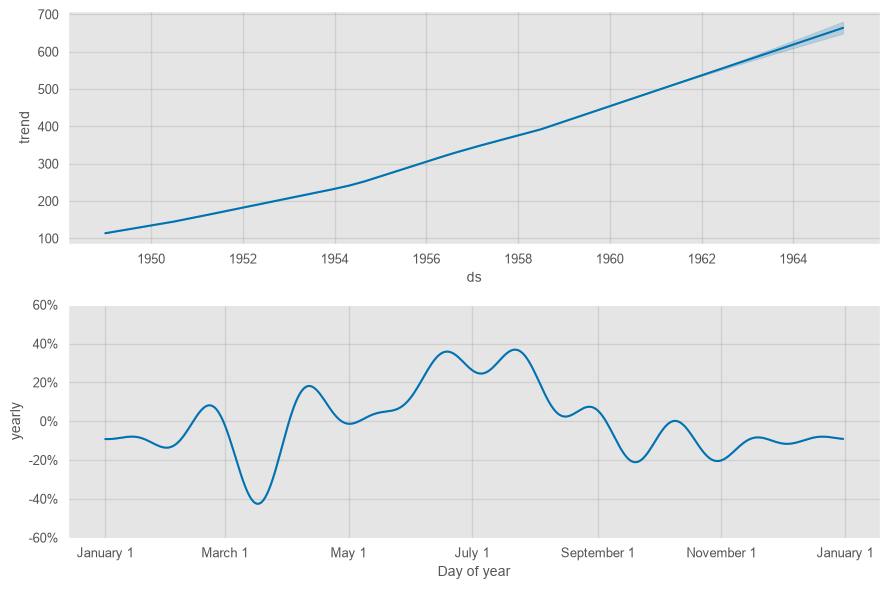

In [76]:
fig = m.plot_components(forecast)

In [77]:
from prophet.diagnostics import cross_validation

df_cv = cross_validation(
    m,
    horizon="365 days",
    period="180 days",
    initial="730 days",
)
df_cv.head()

  0%|          | 0/19 [00:00<?, ?it/s]

17:07:34 - cmdstanpy - INFO - Chain [1] start processing
17:07:43 - cmdstanpy - INFO - Chain [1] done processing
17:07:43 - cmdstanpy - INFO - Chain [1] start processing
17:07:43 - cmdstanpy - INFO - Chain [1] done processing
17:07:43 - cmdstanpy - INFO - Chain [1] start processing
17:07:44 - cmdstanpy - INFO - Chain [1] done processing
17:07:44 - cmdstanpy - INFO - Chain [1] start processing
17:07:44 - cmdstanpy - INFO - Chain [1] done processing
17:07:44 - cmdstanpy - INFO - Chain [1] start processing
17:07:45 - cmdstanpy - INFO - Chain [1] done processing
17:07:45 - cmdstanpy - INFO - Chain [1] start processing
17:07:45 - cmdstanpy - INFO - Chain [1] done processing
17:07:45 - cmdstanpy - INFO - Chain [1] start processing
17:07:45 - cmdstanpy - INFO - Chain [1] done processing
17:07:46 - cmdstanpy - INFO - Chain [1] start processing
17:07:46 - cmdstanpy - INFO - Chain [1] done processing
17:07:46 - cmdstanpy - INFO - Chain [1] start processing
17:07:46 - cmdstanpy - INFO - Chain [1]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,1951-02-01,160.268,159.953,160.588,150,1951-01-18
1,1951-03-01,174.899,173.790,175.994,178,1951-01-18
2,1951-04-01,159.526,157.574,161.401,163,1951-01-18
3,1951-05-01,142.076,139.304,144.618,172,1951-01-18
4,1951-06-01,180.243,175.233,184.631,178,1951-01-18


In [78]:
from prophet.diagnostics import performance_metrics

df_perf_metrics = performance_metrics(df_cv)
df_perf_metrics.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,40 days,324.280,18.008,14.456,0.050,0.039,0.050,0.273
1,42 days,253.172,15.911,12.449,0.044,0.033,0.044,0.318
2,46 days,236.679,15.384,12.537,0.047,0.034,0.046,0.273
3,47 days,244.213,15.627,12.819,0.046,0.034,0.045,0.273
4,48 days,242.234,15.564,12.731,0.046,0.035,0.045,0.273


c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


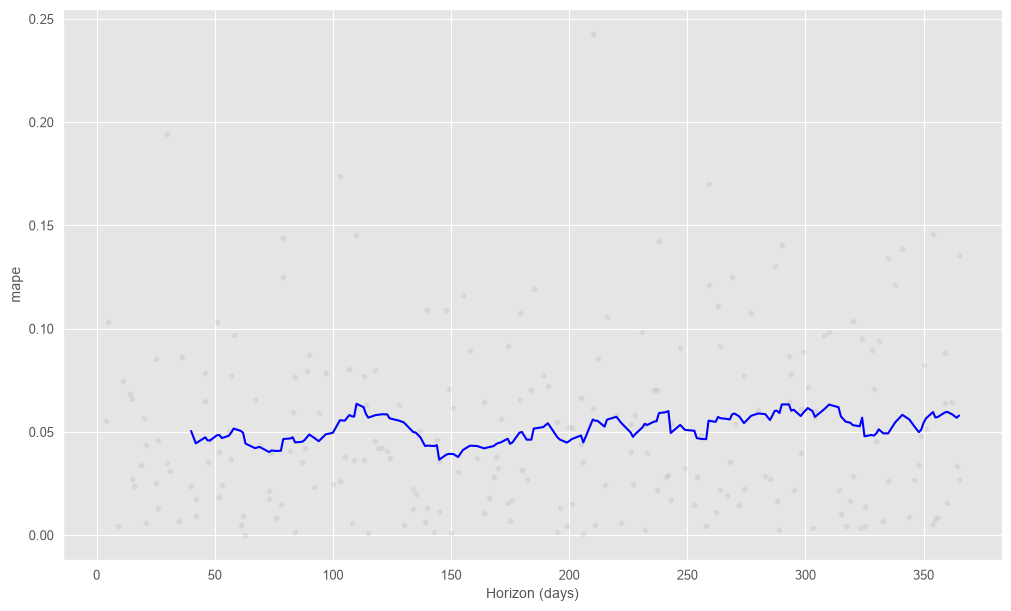

In [79]:
from prophet.plot import plot_cross_validation_metric

fig = plot_cross_validation_metric(df_cv, metric="mape")

# LSTM


## Amazon stock prices


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn

In [81]:
data = pd.read_csv("data/AMZN.csv")
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-05-15,0.122,0.125,0.096,0.098,0.098,1443120000
1,1997-05-16,0.098,0.099,0.085,0.086,0.086,294000000
2,1997-05-19,0.088,0.089,0.081,0.085,0.085,122136000
3,1997-05-20,0.086,0.087,0.082,0.082,0.082,109344000
4,1997-05-21,0.082,0.082,0.069,0.071,0.071,377064000


In [82]:
data = data[["Date", "Close"]]
data.head()

,Date,Close
0,1997-05-15,0.098
1,1997-05-16,0.086
2,1997-05-19,0.085
3,1997-05-20,0.082
4,1997-05-21,0.071


In [83]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

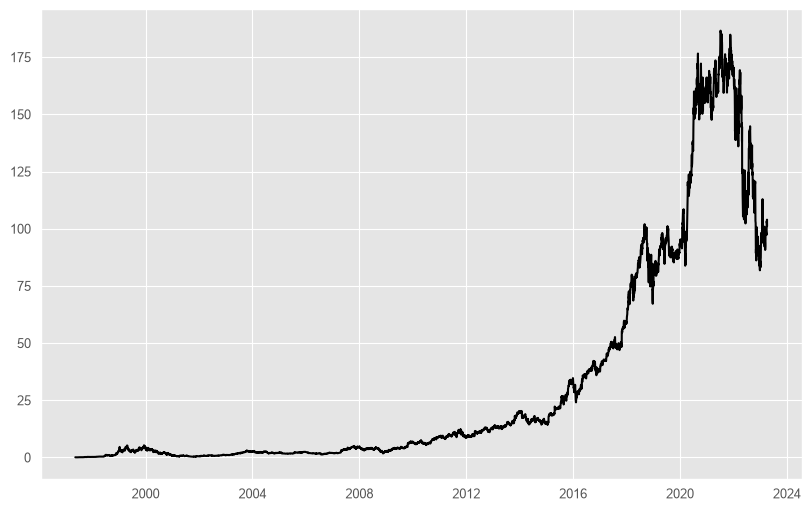

In [84]:
data.Date = pd.to_datetime(data.Date)
plt.plot(data.Date, data.Close)
plt.show()

In [85]:
def prepare_df_for_lstm(data: pd.DataFrame, lookback: int) -> pd.DataFrame:
    df = data.copy()

    df.set_index("Date", inplace=True)
    for i in range(lookback, 0, -1):
        df[f"Close(t-{i})"] = df.Close.shift(i)
    df.dropna(inplace=True)
    return df


lookback = 7
shifted_df = prepare_df_for_lstm(data, lookback)
shifted_df

,Close,Close(t-7),Close(t-6),Close(t-5),Close(t-4),Close(t-3),Close(t-2),Close(t-1)
Date,,,,,,,,
1997-05-27,0.079,0.098,0.086,0.085,0.082,0.071,0.070,0.075
1997-05-28,0.077,0.086,0.085,0.082,0.071,0.070,0.075,0.079
1997-05-29,0.075,0.085,0.082,0.071,0.070,0.075,0.079,0.077
1997-05-30,0.075,0.082,0.071,0.070,0.075,0.079,0.077,0.075
1997-06-02,0.076,0.071,0.070,0.075,0.079,0.077,0.075,0.075
...,...,...,...,...,...,...,...,...
2023-03-30,102.000,100.610,98.700,98.710,98.130,98.040,97.240,100.250
2023-03-31,103.290,98.700,98.710,98.130,98.040,97.240,100.250,102.000
2023-04-03,102.410,98.710,98.130,98.040,97.240,100.250,102.000,103.290


In [86]:
shifted_df_as_np = shifted_df.to_numpy()
shifted_df_as_np

array([[  0.079167,   0.097917,   0.086458, ...,   0.071354,   0.069792,
          0.075   ],
       [  0.076563,   0.086458,   0.085417, ...,   0.069792,   0.075   ,
          0.079167],
       [  0.07526 ,   0.085417,   0.081771, ...,   0.075   ,   0.079167,
          0.076563],
       ...,
       [102.410004,  98.709999,  98.129997, ..., 100.25    , 102.      ,
        103.290001],
       [103.949997,  98.129997,  98.040001, ..., 102.      , 103.290001,
        102.410004],
       [101.099998,  98.040001,  97.239998, ..., 103.290001, 102.410004,
        103.949997]], shape=(6509, 8))

In [87]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
shifted_df_as_np = scaler.fit_transform(shifted_df_as_np)

shifted_df_as_np

array([[-0.99991063, -0.99969839, -0.99982128, ..., -0.99998325,
        -1.        , -0.99995531],
       [-0.99993855, -0.99982128, -0.99983244, ..., -1.        ,
        -0.99994415, -0.99991063],
       [-0.99995253, -0.99983244, -0.99987154, ..., -0.99994415,
        -0.99989946, -0.99993855],
       ...,
       [ 0.09747299,  0.05779984,  0.05158   , ...,  0.07431453,
         0.09308121,  0.10690997],
       [ 0.11398769,  0.05158   ,  0.0506149 , ...,  0.09308121,
         0.10691495,  0.09747299],
       [ 0.08342464,  0.0506149 ,  0.04203581, ...,  0.10691495,
         0.09747802,  0.11398769]], shape=(6509, 8))

In [88]:
X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 1]

X.shape, y.shape

((6509, 7), (6509,))

In [89]:
split_index = int(len(X) * 0.95)

X_train = X[:split_index].reshape((-1, lookback, 1))
X_test = X[split_index:].reshape((-1, lookback, 1))

y_train = y[:split_index].reshape((-1, 1))
y_test = y[split_index:].reshape((-1, 1))

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((6183, 7, 1), (326, 7, 1), (6183, 1), (326, 1))

In [90]:
X_train = torch.tensor(X_train).float()
X_test = torch.tensor(X_test).float()
y_train = torch.tensor(y_train).float()
y_test = torch.tensor(y_test).float()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([6183, 7, 1]),
 torch.Size([326, 7, 1]),
 torch.Size([6183, 1]),
 torch.Size([326, 1]))

In [91]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 16
train_loader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False
)

for X_batch, y_batch in train_loader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([16, 7, 1])
torch.Size([16, 1])


In [92]:
from typing import Any


class LSTM(nn.Module):
    def __init__(
        self, input_size, hidden_size, num_stacked_layers, *args: Any, **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(
            input_size, hidden_size, num_stacked_layers, batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(
            device
        )
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(
            device
        )
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])

        return out


model = LSTM(1, 4, 1)
model.to(device)

LSTM(
  (lstm): LSTM(1, 4, batch_first=True)
  (fc): Linear(in_features=4, out_features=1, bias=True)
)

In [93]:
def train(model, dataloader, device, optimizer, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)

    model.train()
    train_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        optimizer.zero_grad()

        X, y = X.to(device), y.to(device)

        preds = model(X)
        loss = loss_fn(preds, y)
        train_loss += loss.item()

        loss.backward()
        optimizer.step()

        if batch % 200 == 0:
            print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")
    if batch % 200 != 0:
        print(f"Loss : {loss:>7f} [{(batch + 1)*len(X):>4d} / {size:>4d}]")

    return train_loss / num_batches


def test(model, dataloader, device, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0

    model.eval()
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)

            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()

    test_loss /= num_batches

    print(f"Test Error :\n Avg Loss : {test_loss:>7f} \n")

    return test_loss


def plot_net(data_dict):
    plt.figure(figsize=(8, 5))

    for label, values in data_dict.items():
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

Epoch 1 ------------------------------------------
Loss : 1.850725 [  16 / 6183]
Loss : 0.251519 [3216 / 6183]
Loss : 0.008323 [2709 / 6183]
Test Error :
 Avg Loss : 0.114057 

Epoch 2 ------------------------------------------
Loss : 0.041647 [  16 / 6183]
Loss : 0.003930 [3216 / 6183]
Loss : 0.019877 [2709 / 6183]
Test Error :
 Avg Loss : 0.016777 

Epoch 3 ------------------------------------------
Loss : 0.004900 [  16 / 6183]
Loss : 0.001075 [3216 / 6183]
Loss : 0.000832 [2709 / 6183]
Test Error :
 Avg Loss : 0.009495 

Epoch 4 ------------------------------------------
Loss : 0.002122 [  16 / 6183]
Loss : 0.002151 [3216 / 6183]
Loss : 0.000265 [2709 / 6183]
Test Error :
 Avg Loss : 0.006624 

Epoch 5 ------------------------------------------
Loss : 0.001421 [  16 / 6183]
Loss : 0.000583 [3216 / 6183]
Loss : 0.001492 [2709 / 6183]
Test Error :
 Avg Loss : 0.005287 

Epoch 6 ------------------------------------------
Loss : 0.001953 [  16 / 6183]
Loss : 0.000446 [3216 / 6183]
Loss

C:\Users\USER\AppData\Local\Temp\ipykernel_13920\2117950679.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


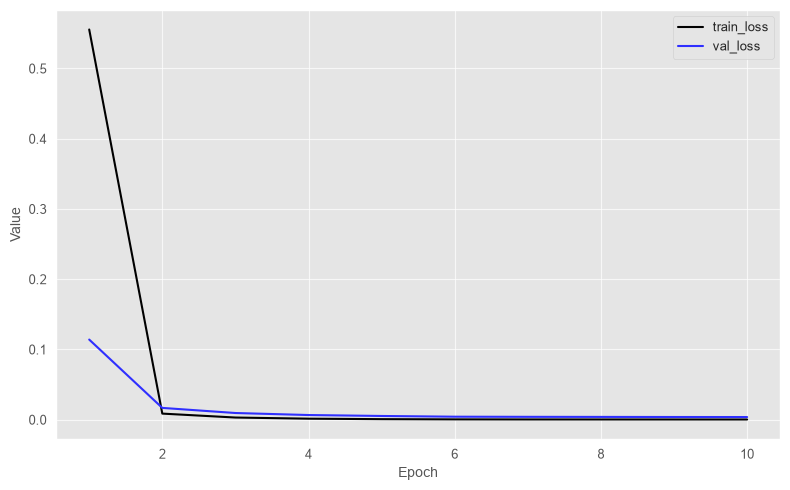

In [94]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history = {"train_loss": [], "val_loss": []}


epochs = 10
for epoch in range(epochs):
    print(f"Epoch {epoch + 1} ------------------------------------------")
    train_loss = train(model, train_loader, device, optimizer, loss_fn)
    val_loss = test(model, test_loader, device, loss_fn)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

plot_net(history)

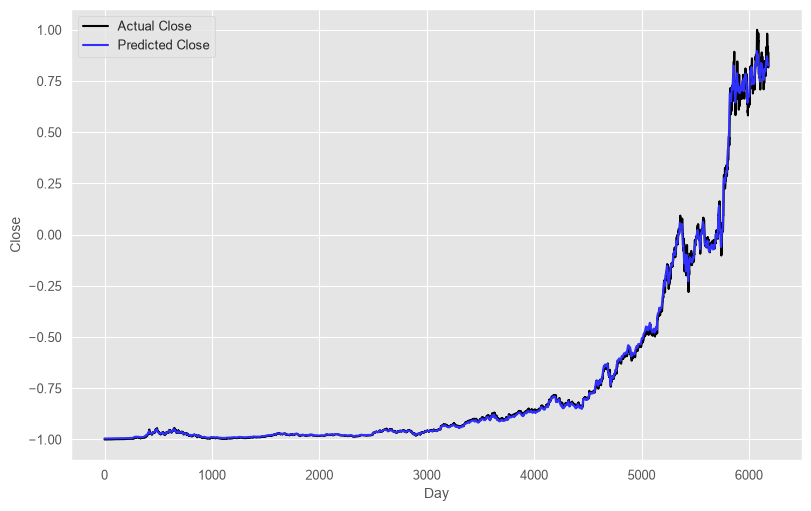

In [95]:
with torch.no_grad():
    predicted = model(X_train.to(device)).cpu().numpy()


plt.plot(y_train, label="Actual Close")
plt.plot(predicted, label="Predicted Close")
plt.xlabel("Day")
plt.ylabel("Close")
plt.legend()
plt.show()

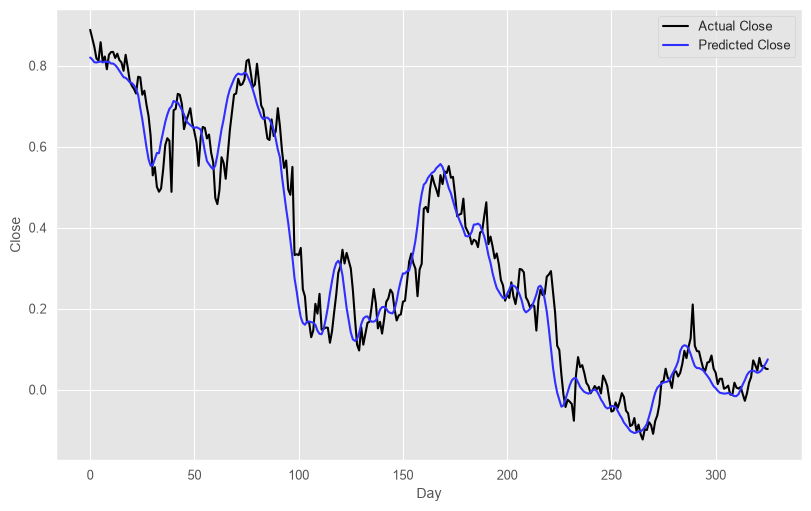

In [96]:
with torch.no_grad():
    predicted = model(X_test.to(device)).cpu().numpy()


plt.plot(y_test, label="Actual Close")
plt.plot(predicted, label="Predicted Close")
plt.xlabel("Day")
plt.ylabel("Close")
plt.legend()
plt.show()

## Airline Passengers


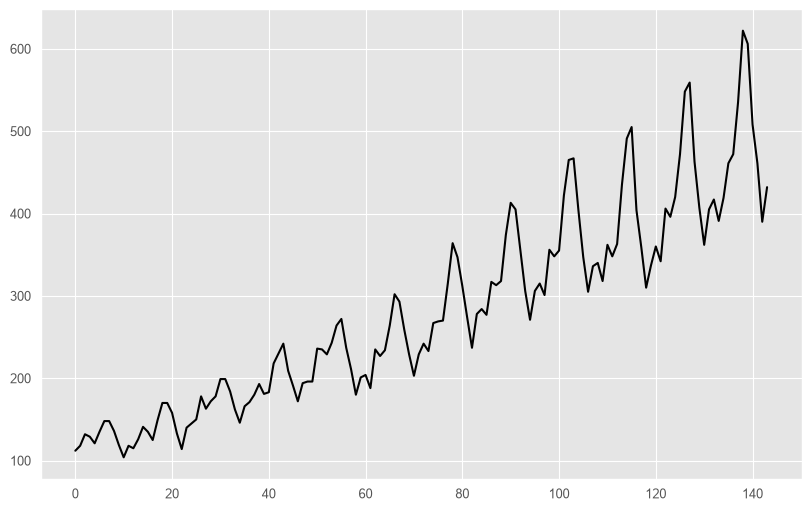

In [97]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data/airline-passengers.csv").rename(columns={"Month": "ds"})
timeseries = df[["Passengers"]].values.astype("float32")

plt.plot(timeseries)
plt.show()

In [98]:
def prepare_df_for_lstm(df, lookback):
    data = df.copy()

    df.set_index("ds", inplace=True)
    for i in range(lookback, 0, -1):
        df[f"Passengers(t-{i})"] = df.Passengers.shift(i)
    df.dropna(inplace=True)
    return df


lookback = 4
shifted_df = prepare_df_for_lstm(df, lookback)
shifted_df

,Passengers,Passengers(t-4),Passengers(t-3),Passengers(t-2),Passengers(t-1)
ds,,,,,
1949-05,121,112.0,118.0,132.0,129.0
1949-06,135,118.0,132.0,129.0,121.0
1949-07,148,132.0,129.0,121.0,135.0
1949-08,148,129.0,121.0,135.0,148.0
1949-09,136,121.0,135.0,148.0,148.0
...,...,...,...,...,...
1960-08,606,461.0,472.0,535.0,622.0
1960-09,508,472.0,535.0,622.0,606.0
1960-10,461,535.0,622.0,606.0,508.0


In [99]:
from torch.utils.data import TensorDataset, DataLoader

shifted_df_as_np = shifted_df.to_numpy()

X = shifted_df_as_np[:, 1:]
y = shifted_df_as_np[:, 1]

split_index = int(len(shifted_df_as_np) * 0.65)

X_train = torch.tensor(X[:split_index].reshape((-1, lookback, 1))).float()
X_test = torch.tensor(X[split_index:].reshape((-1, lookback, 1))).float()
y_train = torch.tensor(y[:split_index].reshape((-1, 1))).float()
y_test = torch.tensor(y[split_index:].reshape((-1, 1))).float()

batch_size = 16
train_dataloader = DataLoader(
    TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False
)
test_dataloader = DataLoader(
    TensorDataset(X_test, y_test), batch_size=batch_size, shuffle=False
)

for X_batch, y_batch in train_dataloader:
    print(X_batch.shape)
    print(y_batch.shape)
    break

torch.Size([16, 4, 1])
torch.Size([16, 1])


In [100]:
from typing import Any


class AirModel(nn.Module):
    def __init__(
        self, input_size, hidden_size, num_layers, *args: Any, **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.shape[0]
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

Epoch 1------------------------------------------
Loss : 16329.662109 [  16 /   91]
Loss : 97390.000000 [  66 /   91]
Test Error :
 Avg Loss : 214495.343750 

Epoch 2------------------------------------------
Loss : 16271.520508 [  16 /   91]
Loss : 97181.695312 [  66 /   91]
Test Error :
 Avg Loss : 214187.378906 

Epoch 3------------------------------------------
Loss : 16195.492188 [  16 /   91]
Loss : 97059.367188 [  66 /   91]
Test Error :
 Avg Loss : 213999.281250 

Epoch 4------------------------------------------
Loss : 16144.363281 [  16 /   91]
Loss : 96924.710938 [  66 /   91]
Test Error :
 Avg Loss : 213804.660156 

Epoch 5------------------------------------------
Loss : 16091.707031 [  16 /   91]
Loss : 96770.437500 [  66 /   91]
Test Error :
 Avg Loss : 213574.953125 

Epoch 6------------------------------------------
Loss : 16038.281250 [  16 /   91]
Loss : 96686.687500 [  66 /   91]
Test Error :
 Avg Loss : 213473.992188 

Epoch 7---------------------------------------

C:\Users\USER\AppData\Local\Temp\ipykernel_13920\2117950679.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


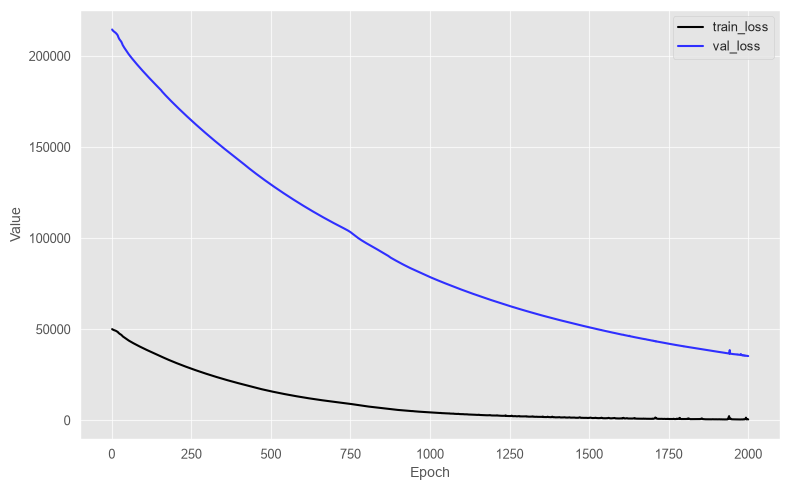

In [101]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AirModel(1, 50, 1).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters())

history_dict = {"train_loss": [], "val_loss": []}

epochs = 2000
for epoch in range(epochs):
    print(f"Epoch {epoch+1}------------------------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    test_loss = test(model, test_dataloader, device, loss_fn)

    history_dict["train_loss"].append(train_loss)
    history_dict["val_loss"].append(test_loss)

plot_net(history_dict)

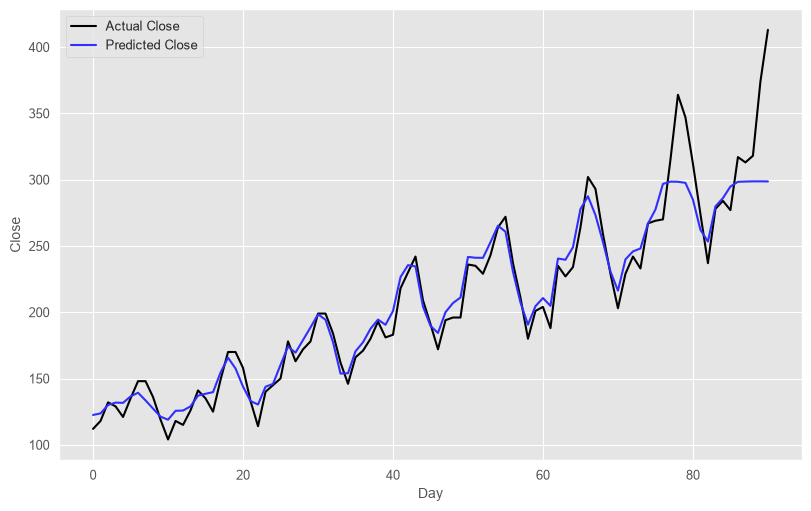

In [102]:
with torch.no_grad():
    predicted = model(X_train.to(device)).cpu().numpy()


plt.plot(y_train, label="Actual Close")
plt.plot(predicted, label="Predicted Close")
plt.xlabel("Day")
plt.ylabel("Close")
plt.legend()
plt.show()

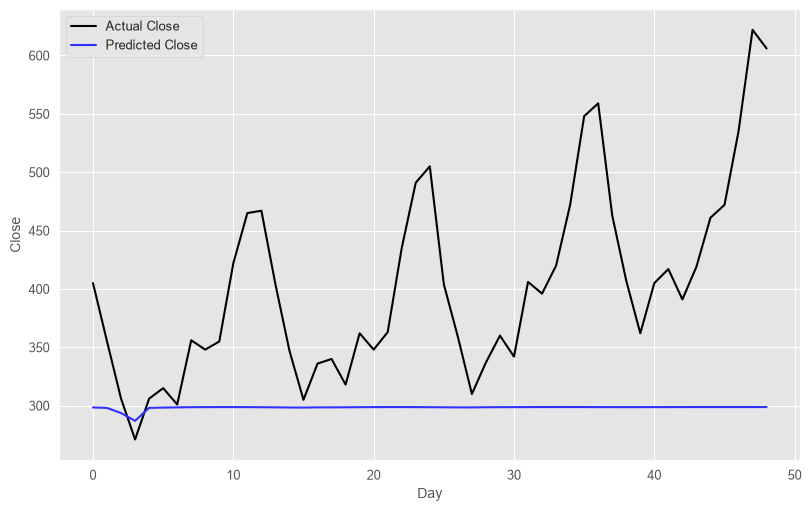

In [103]:
with torch.no_grad():
    predicted = model(X_test.to(device)).cpu().numpy()


plt.plot(y_test, label="Actual Close")
plt.plot(predicted, label="Predicted Close")
plt.xlabel("Day")
plt.ylabel("Close")
plt.legend()
plt.show()

## Multivariate Time Series


In [104]:
url = r"https://raw.githubusercontent.com/jbrownlee/Datasets/master/pollution.csv"

dataset = pd.read_csv(url)

dataset["date"] = pd.to_datetime(dataset[["year", "month", "day", "hour"]])
dataset.set_index("date", inplace=True)
dataset.drop(columns=["year", "month", "day", "hour", "No"], inplace=True)
dataset.columns = [
    "pollution",
    "dew",
    "temp",
    "press",
    "wnd_dir",
    "wnd_spd",
    "snow",
    "rain",
]
dataset["pollution"] = dataset["pollution"].fillna(0)
dataset = dataset[24:]

dataset.to_csv("data/pollution.csv")
dataset.head()

,pollution,dew,temp,press,wnd_dir,wnd_spd,snow,rain
date,,,,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,SE,6.25,2,0


C:\Users\USER\AppData\Local\Temp\ipykernel_13920\2112923845.py:12: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


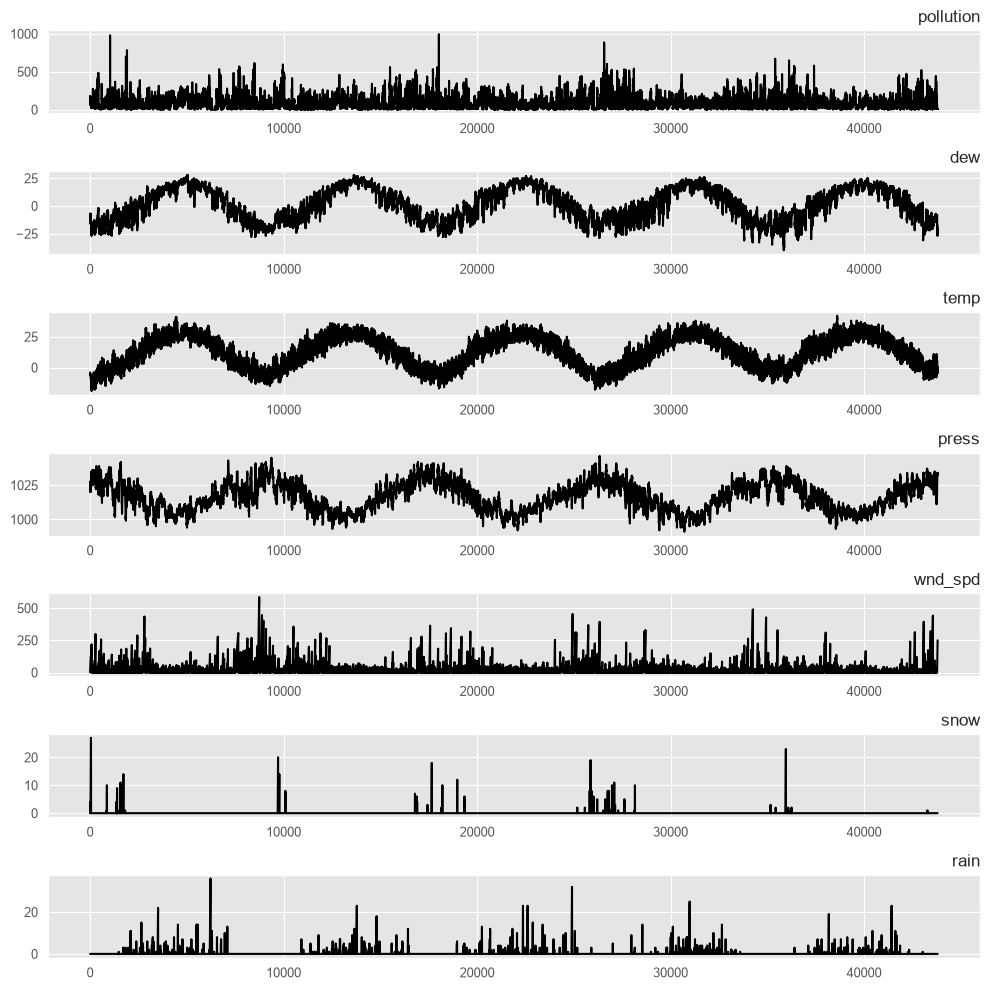

In [105]:
df = pd.read_csv("data/pollution.csv", header=0, index_col=0)
values = df.values
groups = [0, 1, 2, 3, 5, 6, 7]
i = 1

plt.figure(figsize=(10, 10))
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group])
    plt.title(df.columns[group], loc="right")
    i += 1
plt.tight_layout()
plt.show()

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null  object 
 5   wnd_spd    43800 non-null  float64
 6   snow       43800 non-null  int64  
 7   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 3.0+ MB


In [107]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

encoder = LabelEncoder()
df.wnd_dir = encoder.fit_transform(df.wnd_dir)

In [108]:
values = df.values.astype("float32")

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(values)

In [109]:
def create_sequences(data, lookback):
    xs, ys = [], []
    for i in range(len(data) - lookback):
        x = data[i : (i + lookback)]
        y = data[i + lookback, 0]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)


lookback = 24
X, y = create_sequences(scaled_data, lookback)

In [110]:
from torch.utils.data import TensorDataset, DataLoader

split_index = 365 * 24 * 3

X_train, X_test = torch.tensor(X[:split_index]), torch.tensor(X[split_index:])
y_train= torch.tensor(y[:split_index]).reshape((-1, 1))
y_test = torch.tensor(y[split_index:]).reshape((-1, 1))

batch_size = 64
train_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size, shuffle=True)
test_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size, shuffle=False)

In [111]:
from typing import Any


class AirPollutionLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers,
        output_size,
        *args: Any,
        **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)

        self.num_layers = num_layers
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        batch_size = x.shape[0]
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)
        out, (h0, c0) = self.lstm(x, (h0, c0))
        pred = self.fc(out[:, -1, :])
        return pred

Epoch1----------------------------------------------------
Loss : 0.025631 [  64 / 26280]
Loss : 0.001438 [12864 / 26280]
Loss : 0.000544 [25664 / 26280]
Loss : 0.000653 [16440 / 26280]
Test Error :
 Avg Loss : 0.001090 

Epoch2----------------------------------------------------
Loss : 0.002163 [  64 / 26280]
Loss : 0.000699 [12864 / 26280]
Loss : 0.000712 [25664 / 26280]
Loss : 0.000770 [16440 / 26280]
Test Error :
 Avg Loss : 0.000826 

Epoch3----------------------------------------------------
Loss : 0.000661 [  64 / 26280]
Loss : 0.000560 [12864 / 26280]
Loss : 0.001232 [25664 / 26280]
Loss : 0.002071 [16440 / 26280]
Test Error :
 Avg Loss : 0.000720 

Epoch4----------------------------------------------------
Loss : 0.000203 [  64 / 26280]
Loss : 0.000321 [12864 / 26280]
Loss : 0.000797 [25664 / 26280]
Loss : 0.000384 [16440 / 26280]
Test Error :
 Avg Loss : 0.000755 

Epoch5----------------------------------------------------
Loss : 0.000379 [  64 / 26280]
Loss : 0.000506 [12864

C:\Users\USER\AppData\Local\Temp\ipykernel_13920\2117950679.py:59: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


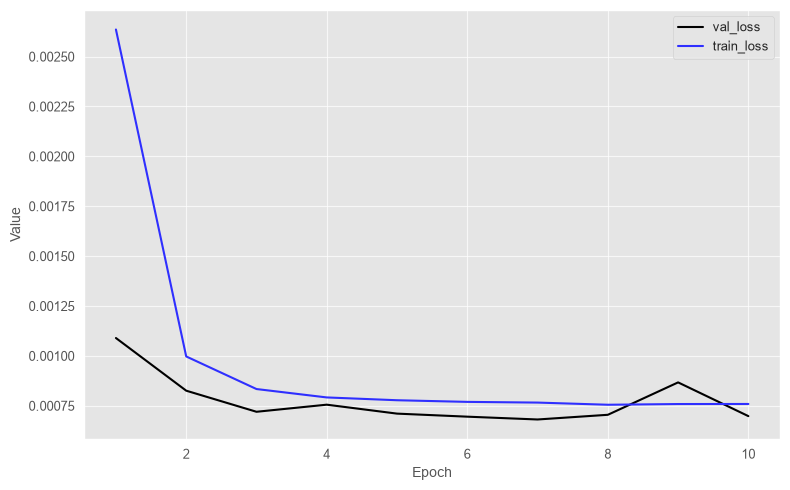

In [112]:
INPUT_SIZE = X_train.shape[2]
HIDDEN_SIZE = 50
NUM_LAYERS = 1
OUTPUT_SIZE = 1

device = "cuda" if torch.cuda.is_available() else "cpu"
model = AirPollutionLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, OUTPUT_SIZE).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

history_dict = {"val_loss": [], "train_loss": []}

epochs = 10
for epoch in range(epochs):
    print(f"Epoch{epoch+1}----------------------------------------------------")
    train_loss = train(model, train_dataloader, device, optimizer, loss_fn)
    val_loss = test(model, test_dataloader, device, loss_fn)

    history_dict["train_loss"].append(train_loss)
    history_dict["val_loss"].append(val_loss)

plot_net(history_dict)

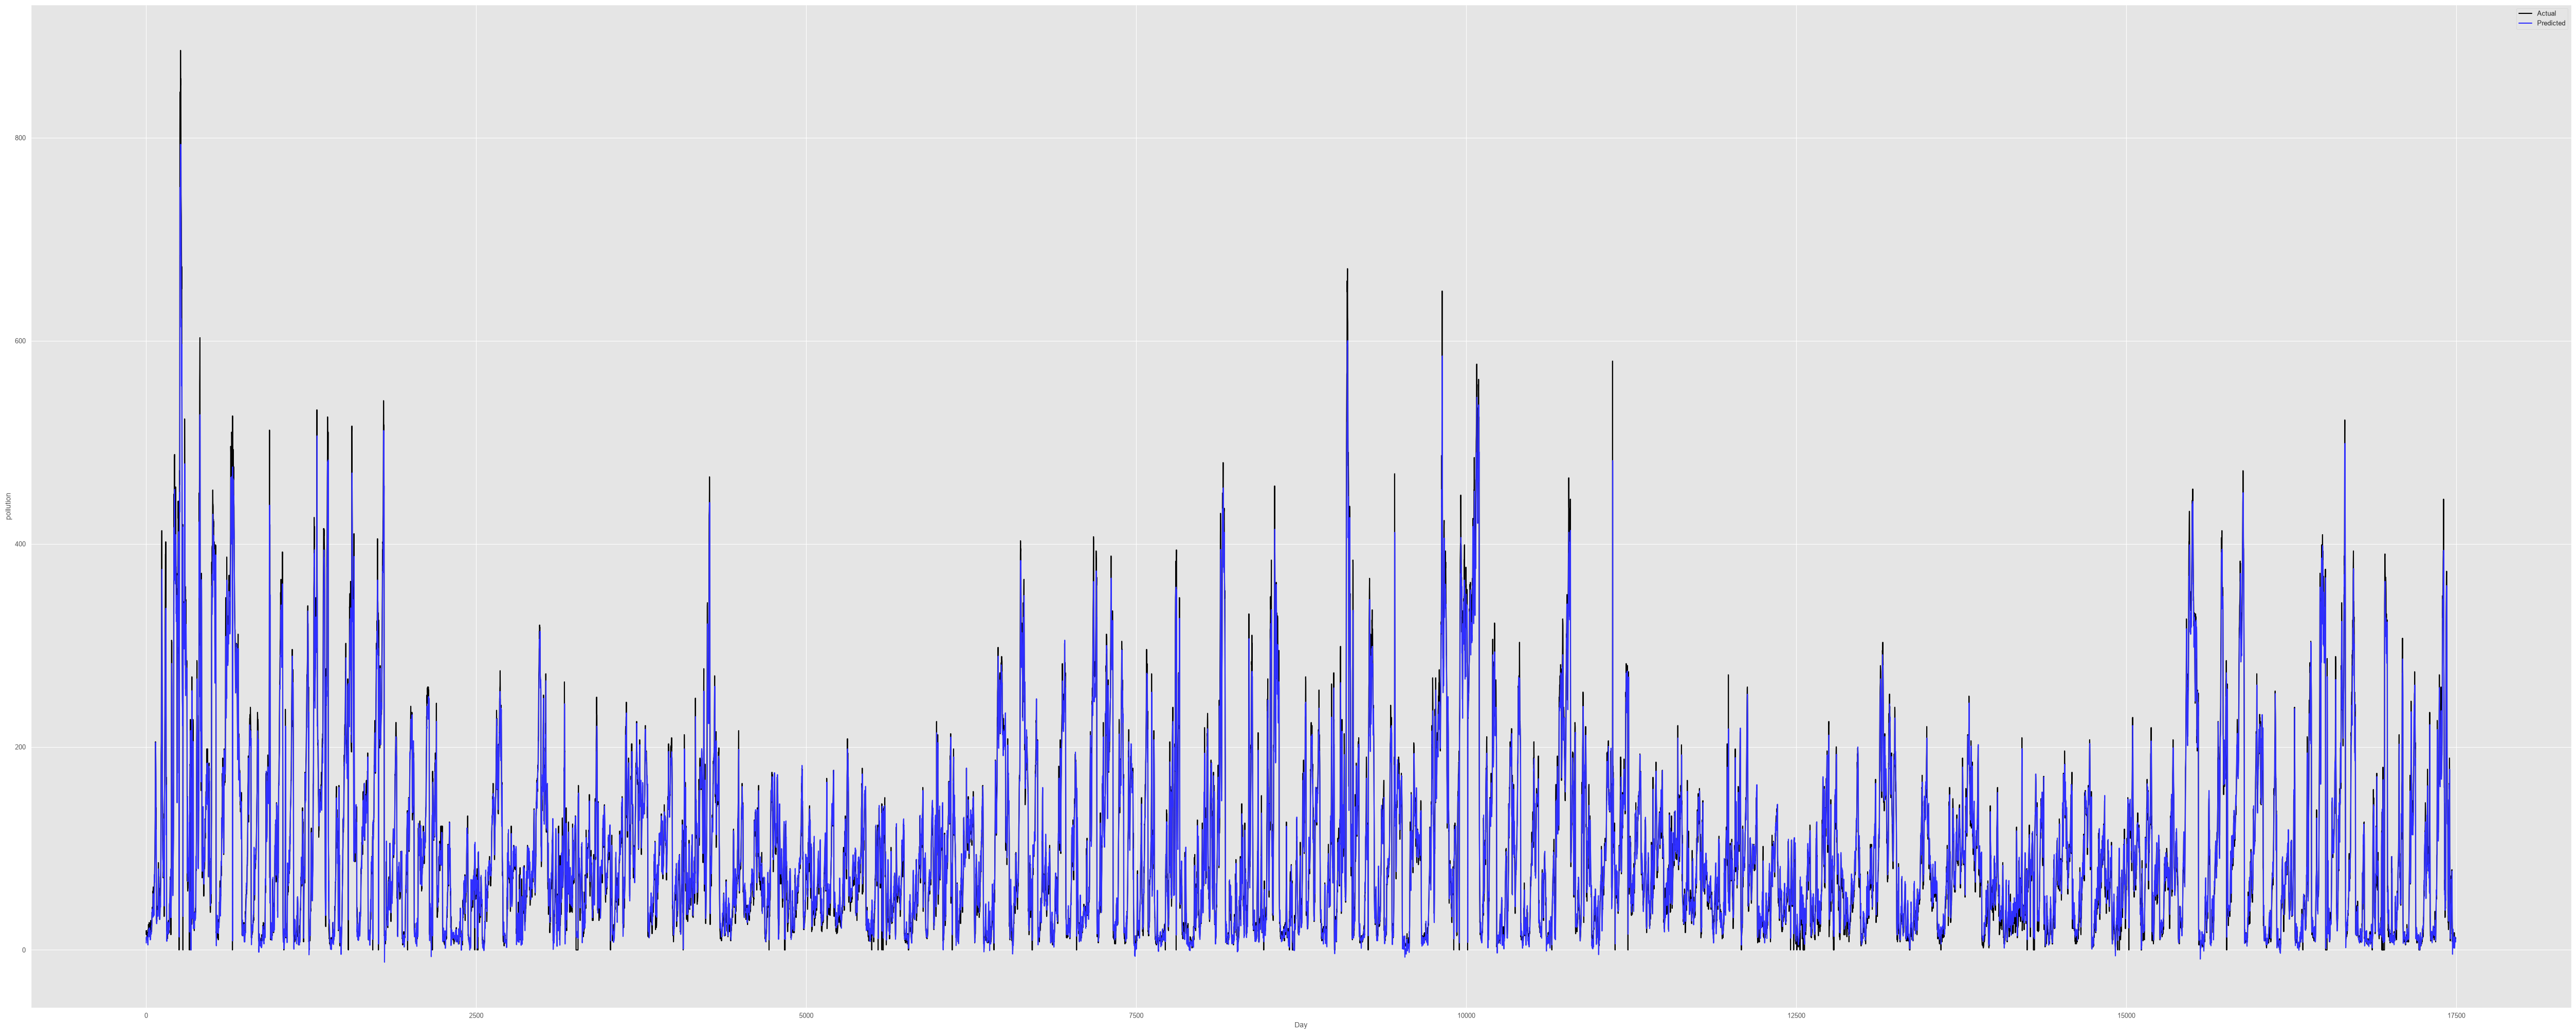

In [113]:
model.eval()
with torch.no_grad():
    test_preds = model(X_test.to(device)).cpu().numpy()

dummy_preds = np.zeros((len(test_preds), INPUT_SIZE))
dummy_preds[:, 0] = test_preds[:, 0]
preds = scaler.inverse_transform(dummy_preds)[:, 0]

dummy_y = np.zeros((len(y_test), INPUT_SIZE))
dummy_y[:, 0] = y_test[:, 0]
y_test_unscaled = scaler.inverse_transform(dummy_y)[:, 0]


plt.figure(figsize=(50, 20))
plt.plot(y_test_unscaled, label="Actual")
plt.plot(preds, label="Predicted")
plt.xlabel("Day")
plt.ylabel("pollution")
plt.legend()
plt.show()

In [114]:
from sklearn.metrics import mean_absolute_error

rmse = np.sqrt(mean_absolute_error(y_test_unscaled,preds))
print(f"Test RMSE: {rmse:.3f}")

Test RMSE: 3.734


In [115]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_unscaled, preds)
print(r2)

0.9248371292405249


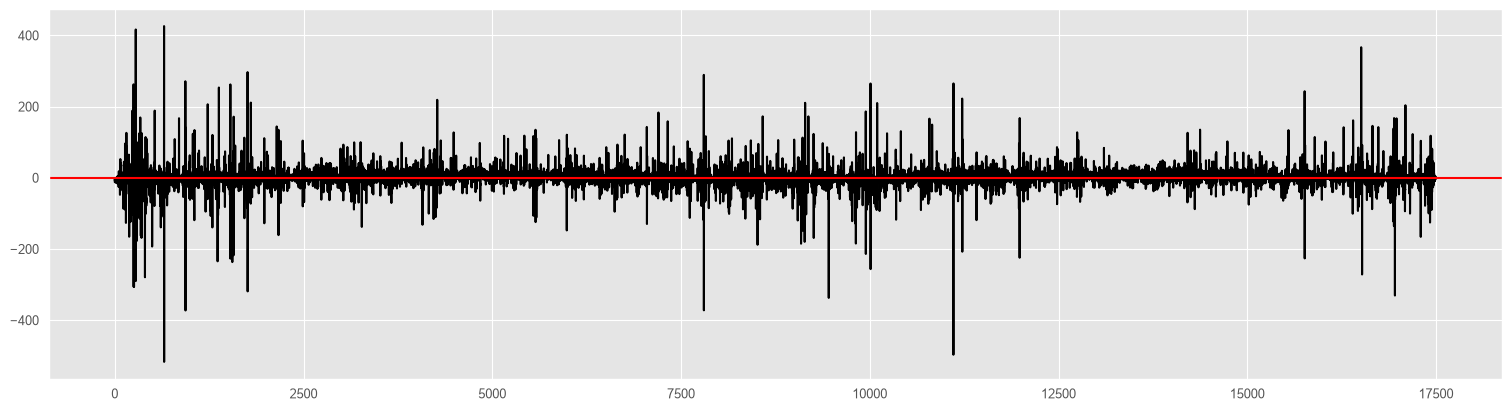

In [116]:
errors = preds - y_test_unscaled

plt.figure(figsize=(15, 4))
plt.plot(errors)
plt.axhline(0, color="red")
plt.show()

# Review 2

In [131]:
data = {
    "Date": [
        "2026-01-01",
        "2026-01-02",
        "2026-01-03",
        "2026-01-04",
        "2026-01-05",
        "2026-01-06",
        "2026-01-07",
        "2026-01-08",
        "2026-01-09",
        "2026-01-10",
        "2026-01-11",
        "2026-01-12",
        "2026-01-13",
        "2026-01-14",
        "2026-01-15",
        "2026-01-16",
        "2026-01-17",
        "2026-01-18",
        "2026-01-19",
        "2026-01-20",
        "2026-01-21",
        "2026-01-22",
        "2026-01-23",
        "2026-01-24",
        "2026-01-25",
        "2026-01-26",
        "2026-01-27",
        "2026-01-28",
        "2026-01-29",
        "2026-01-30",
        "2026-01-31",
        "2026-02-01",
        "2026-02-02",
        "2026-02-03",
        "2026-02-04",
        "2026-02-05",
        "2026-02-06",
        "2026-02-07",
        "2026-02-08",
        "2026-02-09",
        "2026-02-10",
        "2026-02-11",
        "2026-02-12",
        "2026-02-13",
        "2026-02-14",
        "2026-02-15",
        "2026-02-16",
        "2026-02-17",
        "2026-02-18",
        "2026-02-19",
        "2026-02-20",
        "2026-02-21",
        "2026-02-22",
        "2026-02-23",
        "2026-02-24",
        "2026-02-25",
        "2026-02-26",
        "2026-02-27",
        "2026-02-28",
        "2026-03-01",
        "2026-03-02",
        "2026-03-03",
        "2026-03-04",
        "2026-03-05",
        "2026-03-06",
        "2026-03-07",
        "2026-03-08",
        "2026-03-09",
        "2026-03-10",
        "2026-03-11",
        "2026-03-12",
        "2026-03-13",
        "2026-03-14",
        "2026-03-15",
        "2026-03-16",
        "2026-03-17",
        "2026-03-18",
        "2026-03-19",
        "2026-03-20",
        "2026-03-21",
        "2026-03-22",
        "2026-03-23",
        "2026-03-24",
        "2026-03-25",
        "2026-03-26",
        "2026-03-27",
        "2026-03-28",
        "2026-03-29",
        "2026-03-30",
        "2026-03-31",
    ],
    "Sales": [
        157,
        164,
        196,
        153,
        115,
        112,
        120,
        129,
        137,
        168,
        159,
        133,
        128,
        135,
        176,
        181,
        205,
        169,
        132,
        126,
        135,
        142,
        150,
        179,
        174,
        228,
        139,
        144,
        151,
        188,
        194,
        218,
        181,
        143,
        138,
        147,
        154,
        163,
        193,
        187,
        151,
        145,
        152,
        160,
        168,
        199,
        195,
        158,
        153,
        161,
        169,
        176,
        208,
        202,
        166,
        160,
        168,
        175,
        184,
        216,
        211,
        174,
        169,
        177,
        184,
        192,
        224,
        218,
        181,
        176,
        184,
        192,
        200,
        231,
        226,
        189,
        184,
        192,
        248,
        240,
        213,
        207,
        171,
        179,
        187,
        195,
        226,
        221,
        184,
        179,
    ],
    "Promotion": [
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
        1,
        1,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        0,
        1,
    ],
}

df = pd.DataFrame(data)
df.head()

,Date,Sales,Promotion
0,2026-01-01,157,1
1,2026-01-02,164,1
2,2026-01-03,196,1
3,2026-01-04,153,0
4,2026-01-05,115,0


In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Date       90 non-null     object
 1   Sales      90 non-null     int64 
 2   Promotion  90 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 2.2+ KB


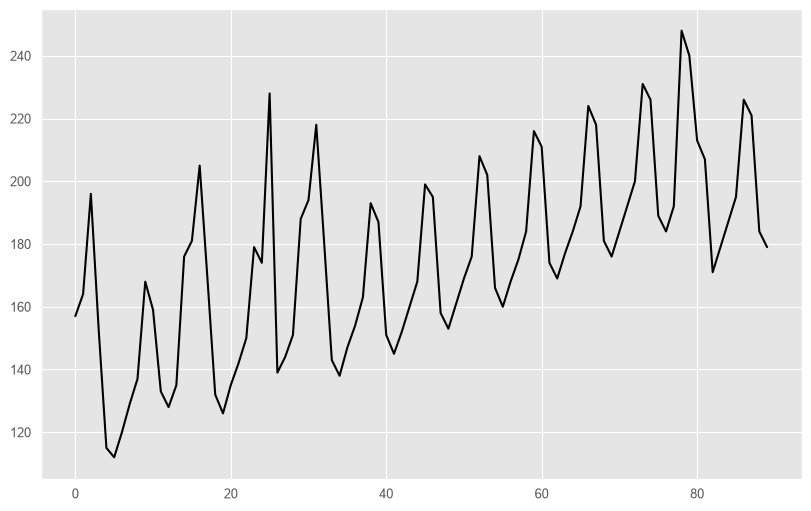

In [133]:
plt.plot(df.Sales)
plt.show()

In [135]:
df = df.rename(columns={"Date":"ds", "Sales":"y"})
df.head()

,ds,y,Promotion
0,2026-01-01,157,1
1,2026-01-02,164,1
2,2026-01-03,196,1
3,2026-01-04,153,0
4,2026-01-05,115,0


In [137]:
df.ds = pd.to_datetime(df.ds)

90

18:20:51 - cmdstanpy - INFO - Chain [1] start processing
18:20:51 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\USER\ipnyb files\uv-envs\forecast-env\.venv\Lib\site-packages\prophet\plot.py:95: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


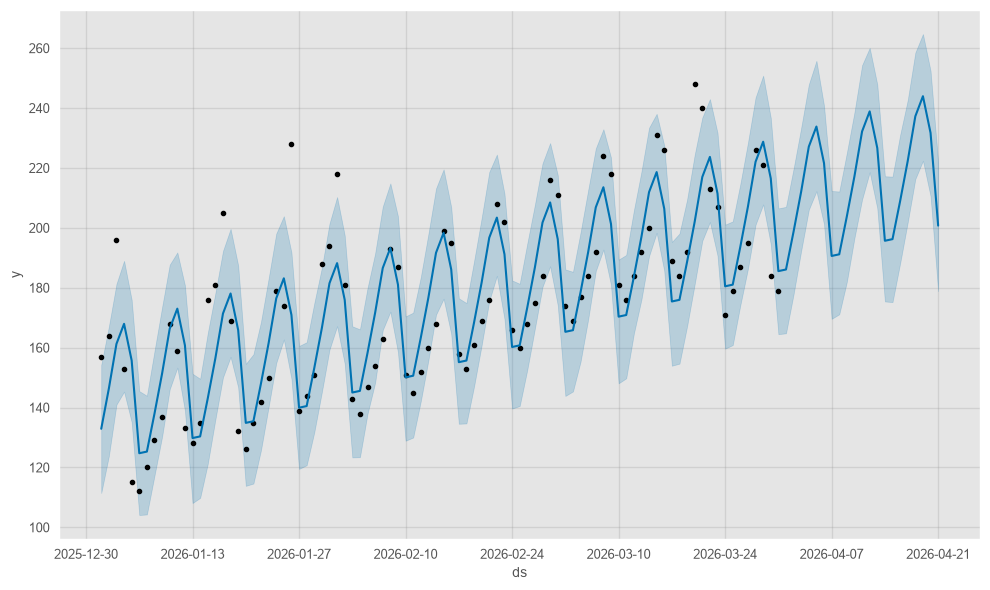

In [140]:
from prophet import Prophet

m = Prophet()
m.fit(df)
future = m.make_future_dataframe(periods=21)
forecast = m.predict(future)
fig = m.plot(forecast)

In [141]:
lstm_df = df[["ds", "y"]]

In [143]:
def prep_df_for_lstm(data, lookback):
    df = data.copy()
    df.set_index("ds", inplace=True)

    for i in range(lookback, 0, -1):
        df[f"y(t-{i})"] = df["y"].shift(i)
    df.dropna(inplace=True)
    return df

lookback = 4
shifted_df = prep_df_for_lstm(lstm_df, lookback)
shifted_df.head()

,y,y(t-4),y(t-3),y(t-2),y(t-1)
ds,,,,,
2026-01-05,115,157.0,164.0,196.0,153.0
2026-01-06,112,164.0,196.0,153.0,115.0
2026-01-07,120,196.0,153.0,115.0,112.0
2026-01-08,129,153.0,115.0,112.0,120.0
2026-01-09,137,115.0,112.0,120.0,129.0


In [146]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1,1))
scaled_data = scaler.fit_transform(shifted_df)

scaled_data

array([[-0.95588235, -0.33823529, -0.23529412,  0.23529412, -0.39705882],
       [-1.        , -0.23529412,  0.23529412, -0.39705882, -0.95588235],
       [-0.88235294,  0.23529412, -0.39705882, -0.95588235, -1.        ],
       [-0.75      , -0.39705882, -0.95588235, -1.        , -0.88235294],
       [-0.63235294, -0.95588235, -1.        , -0.88235294, -0.75      ],
       [-0.17647059, -1.        , -0.88235294, -0.75      , -0.63235294],
       [-0.30882353, -0.88235294, -0.75      , -0.63235294, -0.17647059],
       [-0.69117647, -0.75      , -0.63235294, -0.17647059, -0.30882353],
       [-0.76470588, -0.63235294, -0.17647059, -0.30882353, -0.69117647],
       [-0.66176471, -0.17647059, -0.30882353, -0.69117647, -0.76470588],
       [-0.05882353, -0.30882353, -0.69117647, -0.76470588, -0.66176471],
       [ 0.01470588, -0.69117647, -0.76470588, -0.66176471, -0.05882353],
       [ 0.36764706, -0.76470588, -0.66176471, -0.05882353,  0.01470588],
       [-0.16176471, -0.66176471, -0.0

In [ ]:
split_index = len(scaled_data) * 0.80

X = scaled_data[:, 1:]
y = scaled_data[:, 0]

X